# Đề tài
# Nhận Diện "Điểm Đen" Tài Chính Và Thiết Lập Mô Hình Thẩm Định Tín Dụng Tự Động

**Problem Statement:**

Trong bối cảnh thị trường tài chính tiêu dùng ngày càng cạnh tranh, NovaBank đang đối mặt với một "nghịch lý" lớn:

* Áp lực tăng trưởng: Cần phê duyệt nhiều khoản vay để tối ưu hóa lợi nhuận.

* Rủi ro hiện hữu: Việc phê duyệt sai (cho vay nhầm khách hàng rủi ro) dẫn đến nợ xấu tăng cao, gây thất thoát vốn nghiêm trọng.

* Hạn chế của phương pháp cũ: Việc xét duyệt thủ công dựa trên cảm quan hoặc các quy tắc cứng nhắc không còn đủ hiệu quả để xử lý dữ liệu lớn và không phản ánh được sự phức tạp trong hành vi tài chính của khách hàng hiện đại.

**Objective:**
* Khám phá và xác định các yếu tố hàng đầu ảnh hưởng đến khả năng nợ xấu
* Sử dụng chỉ số IV (Information Value) và WoE (Weight of Evidence) để xếp hạng mức độ quan trọng của các biến dữ liệu.
* Áp dụng các mô hình máy học trên bộ dữ liệu 30.000 khách hàng để dự đoán xác suất vỡ nợ của các hồ sơ vay mới.




**Data dictionary:**
* client_ID:	Unique identifier for each client
* person_age:	Age of the applicant (years)
* person_income:	Annual income of the applicant (USD)
* person_home_ownership:	Home ownership status (RENT/OWN/MORTGAGE)
* person_emp_length:	Employment length (years)
* loan_intent:	Purpose of the loan (PERSONAL, MEDICAL, EDUCATION, etc.)
* loan_grade:	Credit grade assigned to the loan (A-G)
* loan_amnt:	Requested loan amount (USD)
* loan_int_rate:	Loan interest rate (%)
* loan_status:	Loan repayment status (0 = non-default, 1 = default)
* loan_percent_income:	Percentage of income allocated to loan repayment
* cb_person_default_on_file:	Whether applicant has defaulted previously (Y/N)
* cb_person_cred_hist_length:	Length of credit history (years)
* gender:	Gender of applicant (Male/Female)
* marital_status:	Marital status (Single/Married/Divorced/Widowed)
* education_level:	Education level (High School/Bachelor/Master/PhD)
* country:	Country of residence
* state:	State/Province of residence
* city:	City of residence
* city_latitude:	Latitude coordinate of the city
* city_longitude:	Longitude coordinate of the city
* employment_type:	Employment type (Full-time/Part-time/Self-employed/Unemployed)
* loan_term_months:	Loan term in months (12, 24, 36, 60)
* loan_to_income_ratio:	Loan amount divided by applicant income
* other_debt:	Simulated additional debt held by applicant (USD)
* debt_to_income_ratio:	Total debt obligations divided by applicant income
* open_accounts:	Number of open credit accounts
* credit_utilization_ratio:	Credit utilization ratio (0-1)
* past_delinquencies:	Number of past delinquencies/late payments




* client_ID:	Mã định danh duy nhất cho mỗi khách hàng
* person_age:	Tuổi của người nộp đơn (năm)
* person_income:	Thu nhập hàng năm của người nộp đơn (USD)
* person_home_ownership:	Tình trạng sở hữu nhà (Thuê/Sở hữu/Thế chấp)
* person_emp_length:	Thâm niên làm việc (năm)
* loan_intent:	Mục đích vay (Cá nhân, Y tế, Giáo dục, v.v.)
* loan_grade:	Xếp hạng tín dụng được chỉ định cho khoản vay (A-G)
* loan_amnt:	Số tiền vay yêu cầu (USD)
* loan_int_rate:	Lãi suất vay (%)
* loan_status:	Tình trạng hoàn trả (0 = không nợ xấu, 1 = nợ xấu)
* loan_percent_income:	Tỷ lệ thu nhập dành cho việc trả nợ
* cb_person_default_on_file:	Người nộp đơn đã từng nợ xấu trước đây chưa (Y/N)
* cb_person_cred_hist_length:	Chiều dài lịch sử tín dụng (năm)
* gender:	Giới tính của người nộp đơn (Nam/Nữ)
* marital_status:	Tình trạng hôn nhân (Độc thân/Kết hôn/Ly hôn/Góa)
* education_level:	Trình độ học vấn (Trung học/Cử nhân/Thạc sĩ/Tiến sĩ)
* country:	Quốc gia cư trú
* state:	Bang/Tỉnh cư trú
* city:	Thành phố cư trú
* city_latitude:	Vĩ độ của thành phố
* city_longitude:	Kinh độ của thành phố
* employment_type:	Loại hình công việc (Toàn thời gian/Bán thời gian/Tự doanh/* Thất nghiệp)
* loan_term_months:	Kỳ hạn vay tính theo tháng (12, 24, 36, 60)
* loan_to_income_ratio:	Tỷ lệ khoản vay trên thu nhập
* other_debt:	Khoản nợ bổ sung giả định mà người nộp đơn đang có (USD)
* debt_to_income_ratio:	Tổng nghĩa vụ nợ chia cho thu nhập của người nộp đơn
* open_accounts:	Số lượng tài khoản tín dụng đang mở
* credit_utilization_ratio:	Tỷ lệ sử dụng hạn mức tín dụng (0-1)
* past_delinquencies:	Số lần quá hạn thanh toán/nợ đọng trong quá khứ

# Load thư viện và Load dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({'figure.figsize':(7,3), 'figure.dpi':120})
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from imblearn.over_sampling import SMOTE

In [2]:
!pip install optbinning


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.8/214.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 14.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 5.26.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 5.26.1 which is incompatibl

In [3]:
from optbinning import OptimalBinning
import warnings
warnings.filterwarnings('ignore')

In [4]:
data_link= "https://docs.google.com/spreadsheets/d/1xAB3SvqISbJaQYQhJc70RdgRFiHGFAp9/edit?usp=drive_link&ouid=107768229588762061624&rtpof=true&sd=true"
#Đọc data
# Use the direct export link for Google Sheets, which is more reliable for pd.read_excel
excel_download_link = data_link.split('/edit')[0] + '/export?format=xlsx'
df = pd.read_excel(excel_download_link)

In [5]:
df.head()

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,...,43.6532,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,...,43.6532,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,...,51.6214,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,...,49.2827,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,...,42.8864,-78.8784,Part-time,36,0.643382,15626.153439,0.930628,4,0.228103,0


# Data Preparation / Data Preprocessing / EDA

## Data Understanding

In [6]:
df.shape

# Bộ dữ liệu gồm  32581 dòng và 29 cột

(32581, 29)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  object 
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  object 
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  object 
 6   loan_grade                  32581 non-null  object 
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  object 
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender                      325

In [8]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,city_latitude,city_longitude,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211,45.407613,-63.805473,38.501581,0.170553,1.156796e+04,0.345208,8.042018,0.499884,0.505141
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001,7.644809,46.615580,16.012441,0.107049,1.306093e+04,0.129406,4.328087,0.259530,0.711745
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,29.760400,-123.365600,12.000000,0.000789,2.252074e+02,0.064502,0.000000,0.050001,0.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000,40.712800,-96.797000,24.000000,0.089655,5.387168e+03,0.251236,4.000000,0.275358,0.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000,46.813900,-75.697200,36.000000,0.148148,8.995071e+03,0.333188,8.000000,0.500289,0.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000,51.507400,-3.943600,60.000000,0.229167,1.456293e+04,0.423142,12.000000,0.725056,1.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000,55.953300,-0.127800,60.000000,0.830000,1.187999e+06,1.053888,15.000000,0.949998,6.000000


In [9]:
df.describe(include='object')

,client_ID,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file,gender,marital_status,education_level,country,state,city,employment_type
count,32581,32581,32581,32581,32581,32581,32581,32581,32581,32581,32581,32581
unique,32581,4,6,7,2,2,4,4,3,9,18,4
top,CUST_32581,RENT,EDUCATION,A,N,Male,Single,High School,UK,BC,Victoria,Full-time
freq,1,16446,6453,10777,26836,16371,16368,13185,10944,3679,1852,19473


In [10]:
df.nunique()

,0
client_ID,32581
person_age,58
person_income,4295
person_home_ownership,4
person_emp_length,36
loan_intent,6
loan_grade,7
loan_amnt,753
loan_int_rate,348
loan_status,2


## Data Cleaning
Missing values, Duplicated values, Data Types, Wrong Data, Outliers

In [11]:
df.isna().sum()

# có missing values ở 2 biến: person_emp_length, loan_int_rate

,0
client_ID,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0


In [12]:
# Tỷ lệ null ở các biến loan_int_rate, person_emp_length
print(f"Shape gốc        : {df.shape}")
print(f"loan_int_rate null: {df['loan_int_rate'].isnull().sum()} "
      f"({df['loan_int_rate'].isnull().mean():.1%})")
print(f"person_emp_length null  : {df['person_emp_length'].isnull().sum()} "
      f"({df['person_emp_length'].isnull().mean():.1%})")


Shape gốc        : (32581, 29)
loan_int_rate null: 3116 (9.6%)
person_emp_length null  : 895 (2.7%)


In [13]:
####   loan_int_rate  (3,116 nulls — 9.6%) --> Chiến lược: group median theo loan_grade

print(f'median: {df['loan_int_rate'].median()}')
print(df.groupby('loan_grade')['loan_int_rate'].median().round(2).to_string())

# Lý do: lãi suất do ngân hàng ấn định dựa trực tiếp trên loan_grade.
#        Median theo grade dao động từ 7.49% (Grade A) đến 20.16% (Grade G) — chênh 12.7 điểm %.
#        Dùng global median (11%) để fill Grade G là sai bản chất.



median: 10.99
loan_grade
A     7.49
B    10.99
C    13.48
D    15.31
E    16.82
F    18.54
G    20.16


In [14]:
df['loan_int_rate'] = (
    df.groupby('loan_grade')['loan_int_rate']
      .transform(lambda x: x.fillna(x.median()))
      )

In [15]:
df['loan_int_rate'].isnull().sum() # không còn null

np.int64(0)

In [16]:
#### person_emp_length  (895 nulls — 2.7%)

#Tỷ lệ nợ xấu của toàn data
print(f'Nợ xấu toàn data: {df['loan_status'].mean():.1%}')

# Nợ xấu Chỉ trong nhóm null person_emp_length
null_mask = df['person_emp_length'].isnull()
print(f'Nợ xấu trong nhóm null của person_emp_length: {df[null_mask]['loan_status'].mean():.1%}')

# --> Trong 895 người bỏ trống person_emp_length, cứ 10 người thì có ~3 người vỡ nợ — cao hơn hẳn mức bình thường của toàn dataset.
# Điều này gợi ý rằng những người bỏ trống thời gian làm việc có xu hướng đang trong tình trạng tài chính xấu hơn
# có thể là người thất nghiệp, làm việc không ổn định, hoặc chủ động giấu thông tin vì biết rằng lịch sử việc làm ngắn sẽ bị đánh giá tiêu cực.

Nợ xấu toàn data: 21.8%
Nợ xấu trong nhóm null của person_emp_length: 31.5%


In [17]:
print(df.groupby('employment_type')['person_emp_length'].median().round(2).to_string())


employment_type
Full-time        4.0
Part-time        4.0
Self-employed    4.0
Unemployed       4.0


In [18]:

# ── BƯỚC 1: Chỉ xét rows có giá trị thật để tính median ──────────────
# Không được để null lẫn vào khi tính — median sẽ bỏ qua NaN tự động

df_valid = df[df['person_emp_length'].notna()].copy()

print(f"Rows có giá trị emp_length: {len(df_valid)}")
print(f"Rows bị null (không tính): {df['person_emp_length'].isna().sum()}")

# ── BƯỚC 2: Chia khoảng tuổi ─────────────────────────────────────────
# right=False → khoảng đóng bên trái: [20,25), [25,30), ...
# tức là người 25 tuổi rơi vào nhóm '25-29', không phải '20-24'
bins   = [20, 25, 30, 35, 40, 50, 60, 100]
labels = ['20-24', '25-29', '30-34', '35-39', '40-49', '50-59', '60+']

df_valid['age_group'] = pd.cut(
    df_valid['person_age'],
    bins=bins,
    labels=labels,
    right=False       # [20,25) thay vì (20,25]
)

# ── BƯỚC 3: Tính thống kê theo từng nhóm ─────────────────────────────
result = df_valid.groupby('age_group', observed=True)['person_emp_length'].agg(
    count  = 'count',
    median = 'median',
    mean   = 'mean',
    std    = 'std',
    min    = 'min',
    max    = 'max'
).round(2)

print("\nThống kê person_emp_length theo khoảng tuổi:")
print(result)

Rows có giá trị emp_length: 31686
Rows bị null (không tính): 895

Thống kê person_emp_length theo khoảng tuổi:
           count  median  mean   std  min    max
age_group                                       
20-24      11941     4.0  3.90  3.02  0.0  123.0
25-29      10918     4.0  4.98  3.82  0.0   14.0
30-34       4843     4.0  5.61  4.99  0.0   19.0
35-39       2263     4.0  5.78  5.56  0.0   24.0
40-49       1386     4.0  6.22  6.03  0.0   31.0
50-59        251     4.0  5.71  6.37  0.0   38.0
60+           79     3.0  5.71  8.30  0.0   41.0


Nhận xét:
  - Median đồng đều = 4.0 ở hầu hết nhóm tuổi
  - Mean tăng nhẹ theo tuổi (3.9 → 6.2) nhưng median không đổi
  - → Impute theo age_group và employment_type cho cùng kết quả = 4.0

In [19]:
# Tạo flag trước khi impute — giữ lại signal MNAR
df['emp_length_was_null'] = df['person_emp_length'].isnull().astype(int)
print(f"\nFlag emp_length_was_null — value counts:")
print(df['emp_length_was_null'].value_counts().to_string())


Flag emp_length_was_null — value counts:
emp_length_was_null
0    31686
1      895


In [20]:
# Điền null của person_emp_length là 4.0

df['person_emp_length'] = df['person_emp_length'].fillna(4.0)


In [21]:
print(f'\n→ Nulls còn lại: {df['person_emp_length'].isnull().sum()}')


→ Nulls còn lại: 0


In [22]:
# Kiểm tra wrong data của per_emp_length: người từ đủ 15 tuổi mới được đi làm theo quy định
df[df['person_emp_length'] > (df['person_age'] - 15)]

# Có 2 giá trị bất thường: 21,22 tuổi nhưng có số năm kinh nghiệm là 123 --> drop

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies,emp_length_was_null
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,...,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0,0
210,CUST_00211,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,...,-3.9436,Full-time,36,0.104167,32653.092506,0.274235,6,0.482647,1,0


In [23]:
df = df[(df['person_emp_length'] < 123)]

In [24]:
df.shape

(32579, 30)

In [25]:
df.duplicated().sum()

# không có duplicated

np.int64(0)

In [26]:
df.dtypes

# không có wrong data types

,0
client_ID,object
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,int64
loan_int_rate,float64
loan_status,int64


In [27]:
df.columns

Index(['client_ID', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length', 'gender',
       'marital_status', 'education_level', 'country', 'state', 'city',
       'city_latitude', 'city_longitude', 'employment_type',
       'loan_term_months', 'loan_to_income_ratio', 'other_debt',
       'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio',
       'past_delinquencies', 'emp_length_was_null'],
      dtype='object')

In [28]:
qty_cols = ['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate',
            'loan_percent_income','cb_person_cred_hist_length','loan_term_months','loan_to_income_ratio', 'other_debt',
            'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio',
            'past_delinquencies']

# Kiểm tra xem có giá trị âm nào trong các cột này không và đếm chúng
negative_counts = (df[qty_cols] < 0).sum()
negative_counts

#--> không có giá trị âm ở các cột số lượng

,0
person_age,0
person_income,0
person_emp_length,0
loan_amnt,0
loan_int_rate,0
loan_percent_income,0
cb_person_cred_hist_length,0
loan_term_months,0
loan_to_income_ratio,0
other_debt,0


In [29]:
# Lọc các dòng có tuổi ngoài khoảng 18-100 (KH chưa đủ 18 đi vay và KH có số tuổi bất thường trên 100)
df[(df['person_age'] < 18) | (df['person_age'] > 100)]

# drop 5 dòng giá trị bất thường có số tuổi > 100

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies,emp_length_was_null
81,CUST_00082,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,...,-74.0060,Full-time,24,0.019200,3.865941e+04,0.173838,4,0.080767,0,0
183,CUST_00184,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,...,-123.3656,Full-time,36,0.030000,5.487376e+04,0.304369,1,0.053672,0,0
575,CUST_00576,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,...,-123.1207,Part-time,36,0.254987,2.133409e+04,0.521650,13,0.446131,0,0
747,CUST_00748,123,78000,RENT,7.0,VENTURE,B,20000,10.99,0,...,-78.8784,Full-time,60,0.256410,1.094605e+04,0.396744,7,0.589120,1,0
32297,CUST_32298,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,...,-95.3698,Self-employed,24,0.000833,1.187999e+06,0.198833,8,0.850584,0,0


In [30]:
df = df[df['person_age'] <= 100]

In [31]:
df

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies,emp_length_was_null
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,...,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3,0
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,...,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0,0
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,...,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0,0
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,...,-78.8784,Part-time,36,0.643382,15626.153439,0.930628,4,0.228103,0,0
5,CUST_00006,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,...,-122.4194,Full-time,36,0.252525,2211.741134,0.475933,10,0.827034,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,CUST_32577,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,...,-123.1207,Part-time,36,0.109434,15721.464516,0.406065,11,0.892039,1,0
32577,CUST_32578,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,...,-2.2426,Full-time,60,0.146875,29674.399348,0.394162,6,0.191486,0,0
32578,CUST_32579,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,...,-2.2426,Unemployed,24,0.460526,21098.865051,0.738143,11,0.678980,3,0
32579,CUST_32580,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,...,-122.4194,Self-employed,36,0.100000,26361.525753,0.275744,3,0.223460,1,0


## Univariate Analysis

In [32]:
df.head(2)

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies,emp_length_was_null
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,...,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3,0
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,...,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0,0


##  Numerical

### person_age

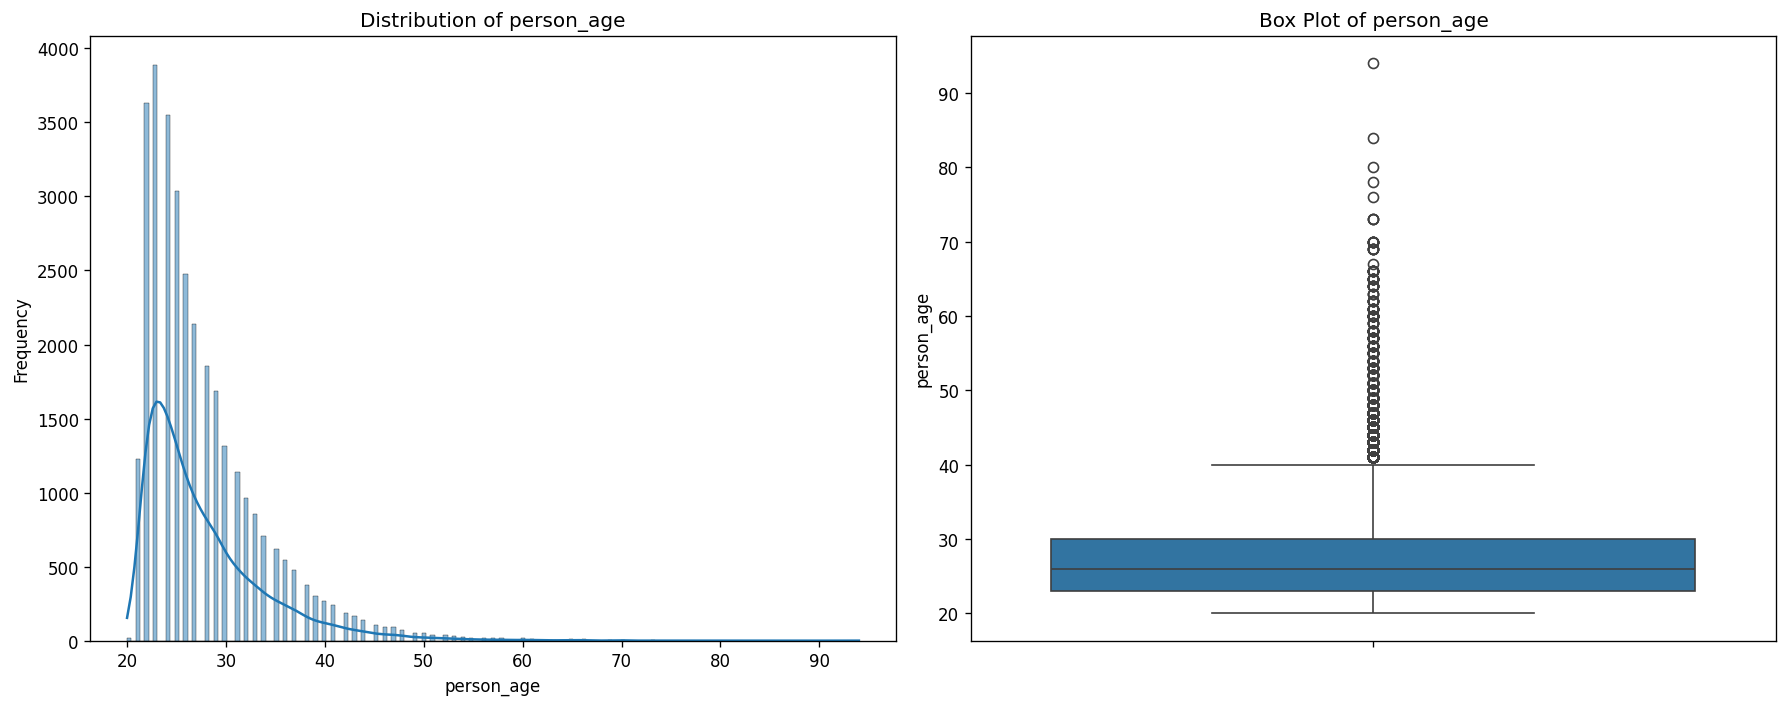

In [33]:
plt.figure(figsize=(15, 6))

# Histogram for person_age
plt.subplot(1, 2, 1)
sns.histplot(df['person_age'], kde=True)
plt.title('Distribution of person_age')
plt.xlabel('person_age')
plt.ylabel('Frequency')

# Box plot for person_age
plt.subplot(1, 2, 2)
sns.boxplot(y=df['person_age'])
plt.title('Box Plot of person_age')
plt.ylabel('person_age')

plt.tight_layout()
plt.show()

- Dataset tập trung vào người vay trẻ — median chỉ 26 tuổi, 75% dưới 30 tuổi.
- Phân phối lệch phải đa số người vay ở độ tuổi 20–30, phần đuôi kéo dài tới 80 tuổi nhưng rất thưa.

--> Đây là đặc trưng của danh mục tín dụng tiêu dùng nhắm vào người đi làm mới.

### person_income

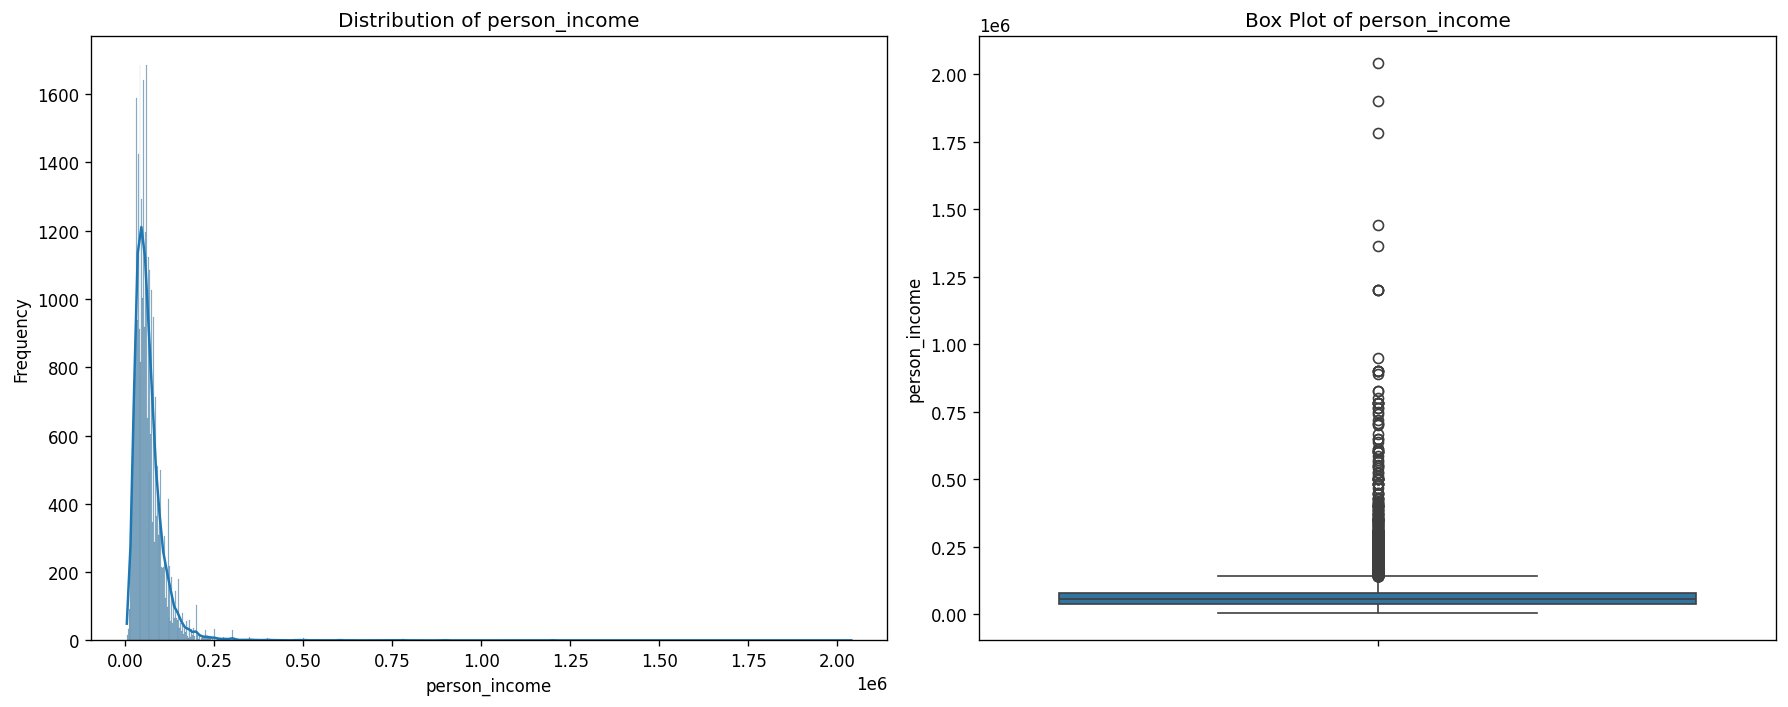

In [34]:
plt.figure(figsize=(15, 6))

# Histogram for person_income
plt.subplot(1, 2, 1)
sns.histplot(df['person_income'], kde=True)
plt.title('Distribution of person_income')
plt.xlabel('person_income')
plt.ylabel('Frequency')

# Box plot for person_income
plt.subplot(1, 2, 2)
sns.boxplot(y=df['person_income'])
plt.title('Box Plot of person_income')
plt.ylabel('person_income')

plt.tight_layout()
plt.show()

- Phân phối lệch phải cực mạnh
- Một số ít người có thu nhập rất cao (max 2M). Thu nhập trung bình là 55k, 75% người vay có thu nhập dưới 79K/năm — đây là tệp khách hàng trung lưu đến trung lưu thấp.

### person_emp_length




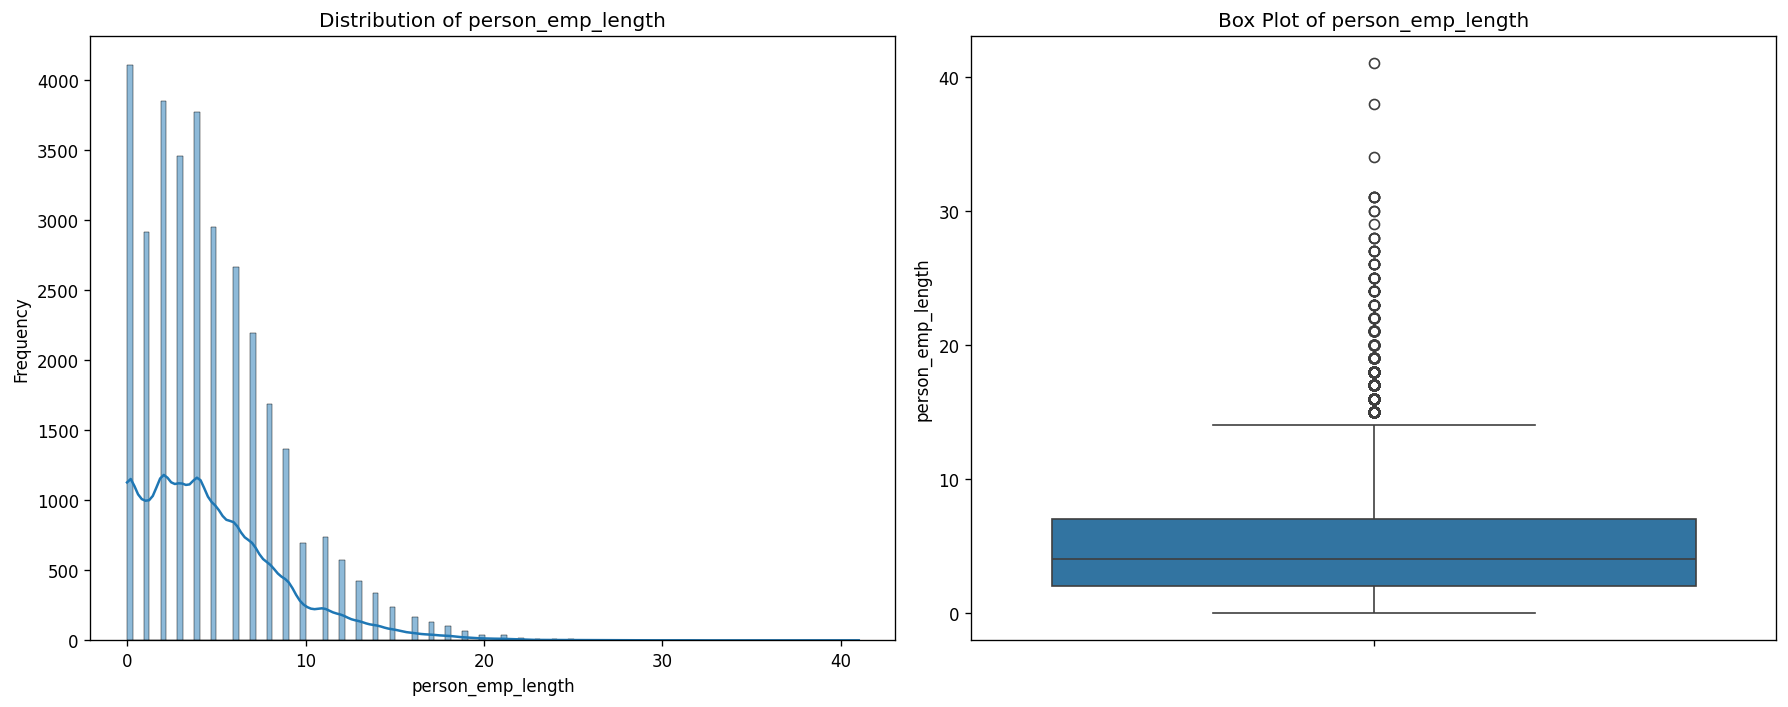

In [35]:
plt.figure(figsize=(15, 6))

# Histogram for person_emp_length
plt.subplot(1, 2, 1)
sns.histplot(df['person_emp_length'], kde=True)
plt.title('Distribution of person_emp_length')
plt.xlabel('person_emp_length')
plt.ylabel('Frequency')

# Box plot for person_emp_length
plt.subplot(1, 2, 2)
sns.boxplot(y=df['person_emp_length'])
plt.title('Box Plot of person_emp_length')
plt.ylabel('person_emp_length')

plt.tight_layout()
plt.show()

Phần lớn người vay có kinh nghiệm làm việc ngắn — 4 năm, 75% dưới 7 năm. Đáng chú ý: 12.9% có kinh nghiệm 0 năm — mới đi làm hoặc đang trong giai đoạn thử việc. Phân phối lệch phải (skew = 1.30) nhất quán với đặc điểm người vay trẻ ở biến person_age.

### loan_amnt

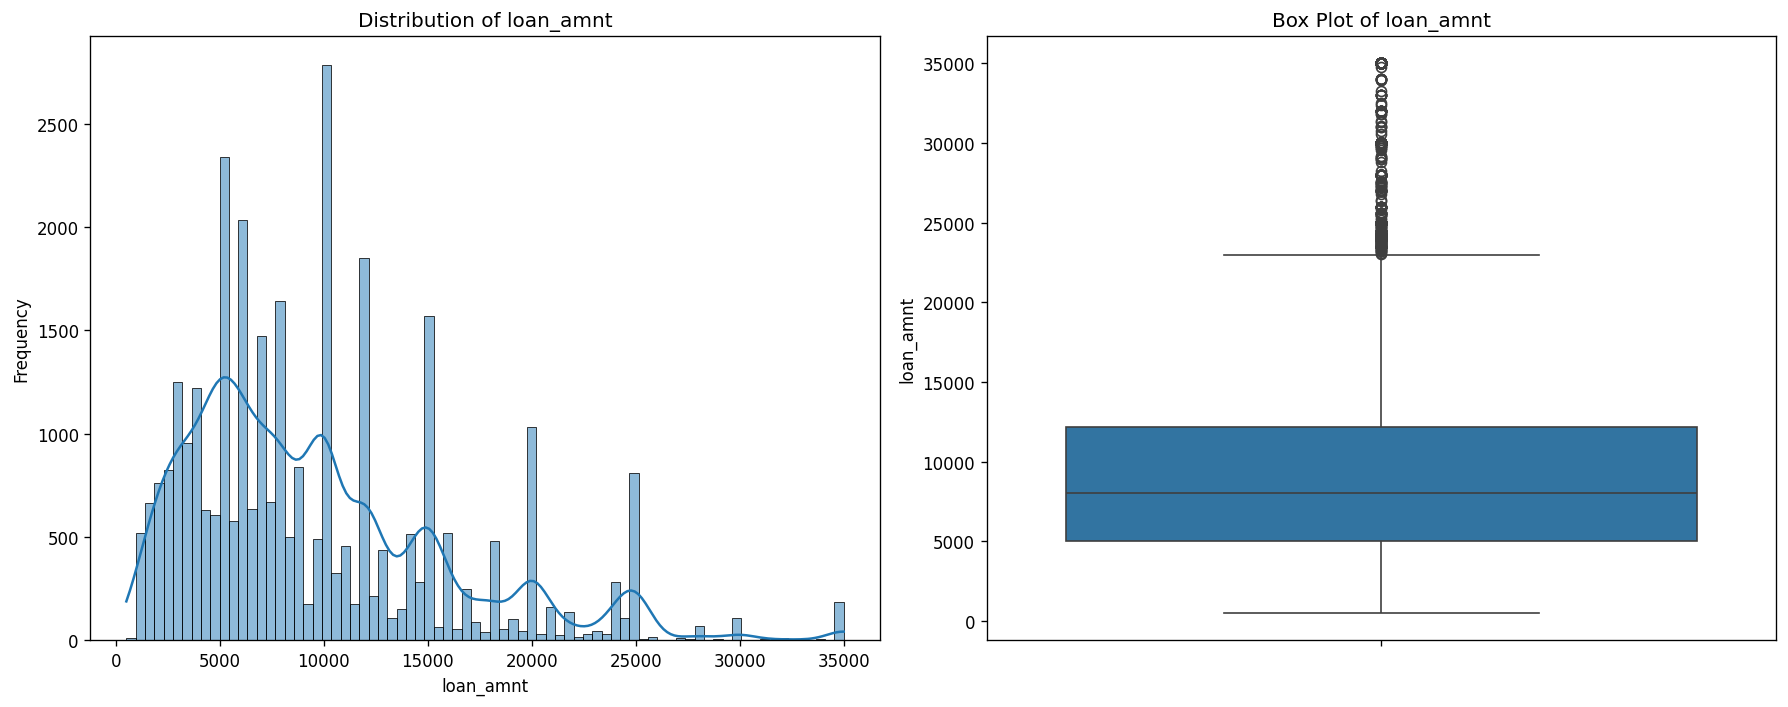

In [36]:
plt.figure(figsize=(15, 6))

# Histogram for loan_amnt
plt.subplot(1, 2, 1)
sns.histplot(df['loan_amnt'], kde=True)
plt.title('Distribution of loan_amnt')
plt.xlabel('loan_amnt')
plt.ylabel('Frequency')

# Box plot for loan_amnt
plt.subplot(1, 2, 2)
sns.boxplot(y=df['loan_amnt'])
plt.title('Box Plot of loan_amnt')
plt.ylabel('loan_amnt')

plt.tight_layout()
plt.show()

- Số tiền vay tập trung ở mức nhỏ đến trung bình — median 8,000, 50% hồ sơ vay dưới 10,000.
- Phân phối lệch phải: đa số người vay nhu cầu không lớn, phần đuôi kéo đến 35,000 nhưng thưa. Đây là đặc trưng của tín dụng tiêu dùng cá nhân, không phải tín dụng kinh doanh.

### loan_int_rate

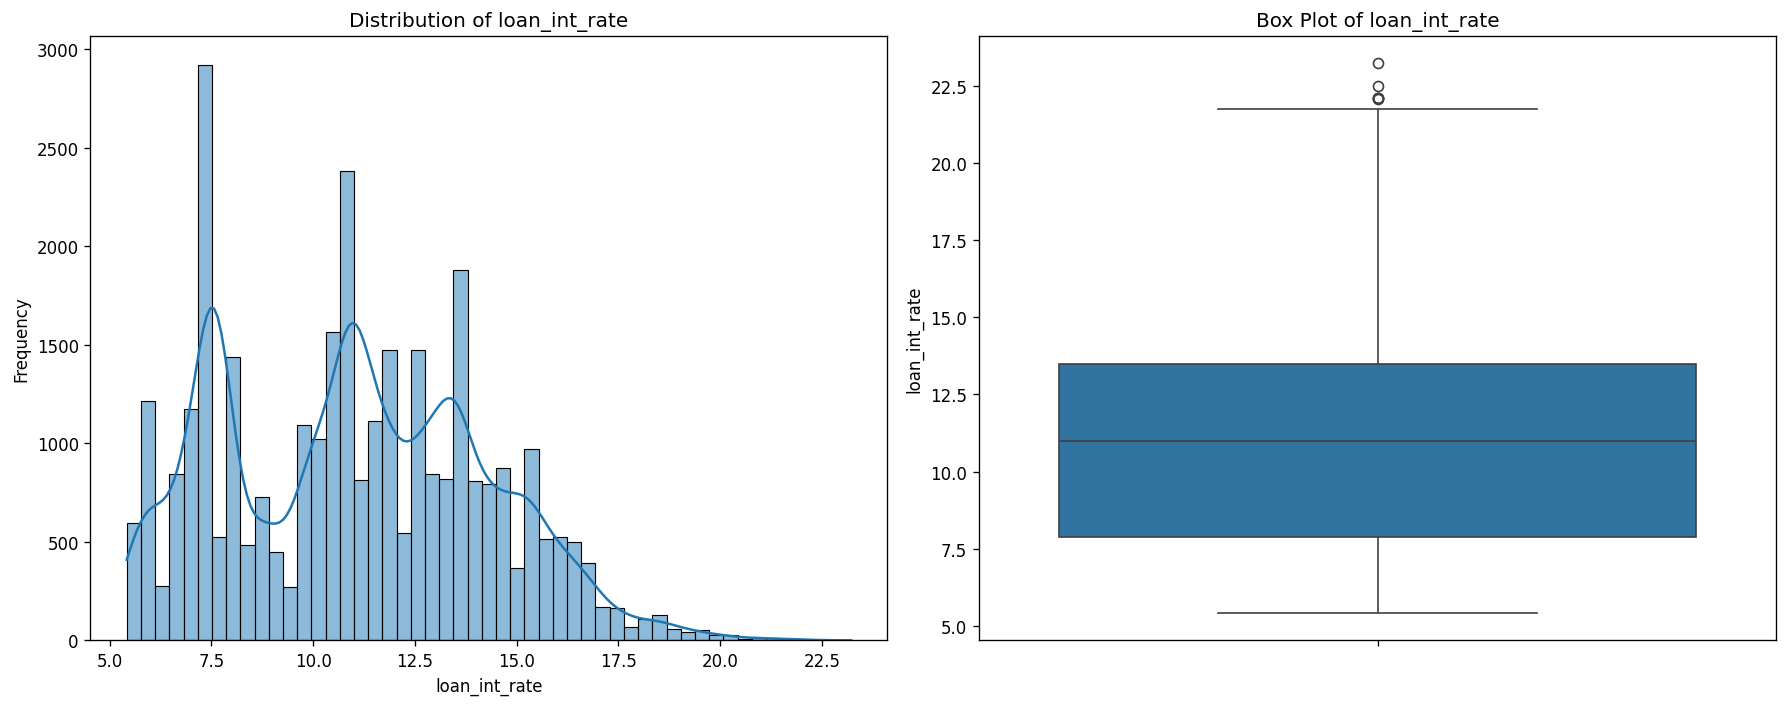

In [37]:
plt.figure(figsize=(15, 6))

# Histogram for loan_int_rate
plt.subplot(1, 2, 1)
sns.histplot(df['loan_int_rate'], kde=True)
plt.title('Distribution of loan_int_rate')
plt.xlabel('loan_int_rate')
plt.ylabel('Frequency')

# Box plot for loan_int_rate
plt.subplot(1, 2, 2)
sns.boxplot(y=df['loan_int_rate'])
plt.title('Box Plot of loan_int_rate')
plt.ylabel('loan_int_rate')

plt.tight_layout()
plt.show()

- Biến số phân phối khá chuẩn, mean và median gần bằng nhau (11.02% vs 10.99%).
- Dải lãi suất từ 5.42% đến 23.22% phản ánh rõ phân khúc Grade A (lãi thấp) đến Grade G (lãi cao). Đây là feature ít bị nhiễu nhất, phù hợp để đưa thẳng vào model mà không cần transform.

### loan_percent_income

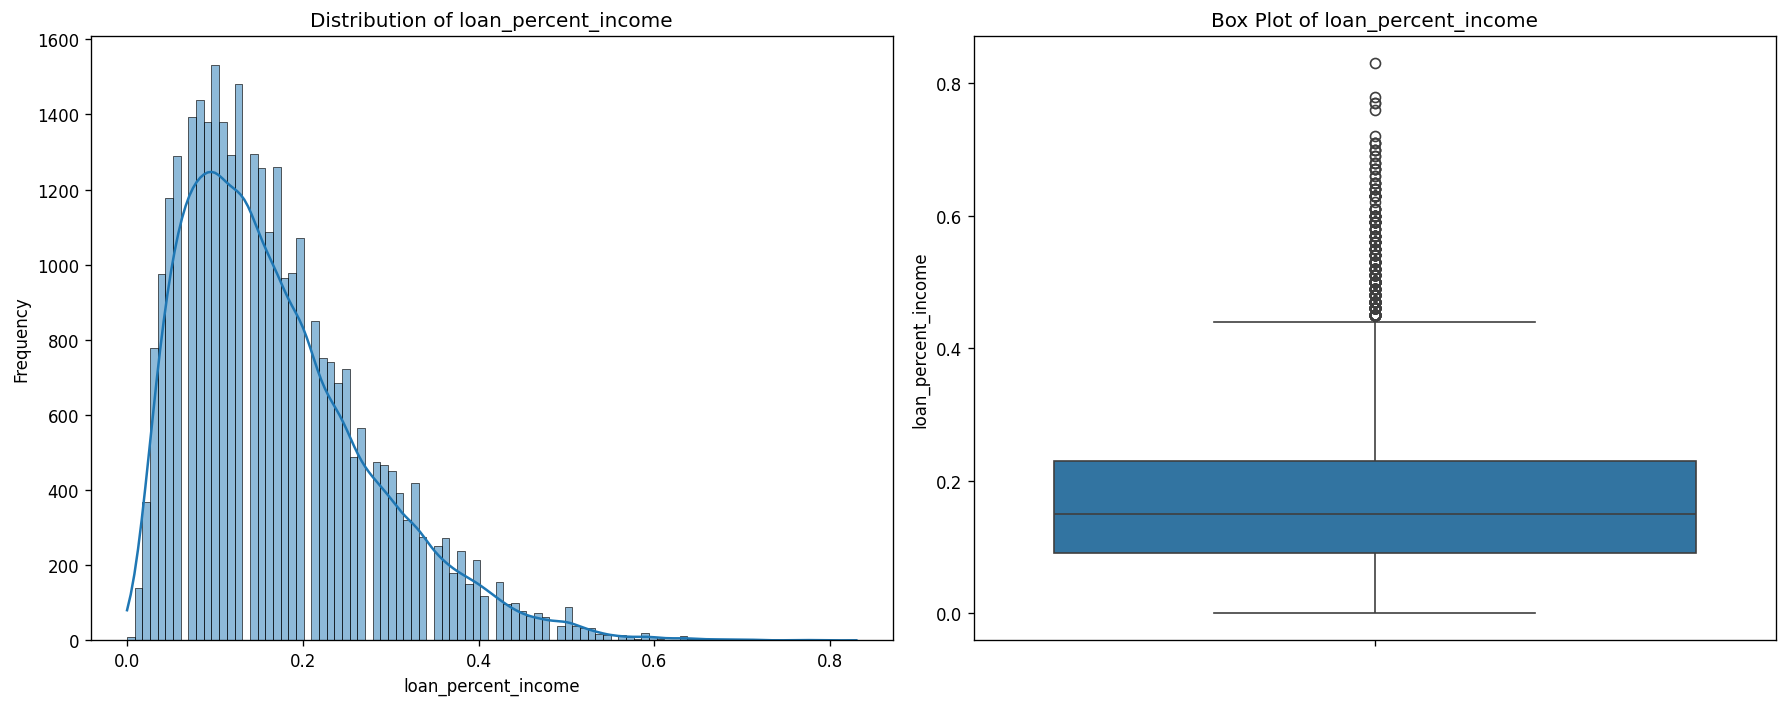

In [38]:
plt.figure(figsize=(15, 6))

# Histogram for loan_int_rate
plt.subplot(1, 2, 1)
sns.histplot(df['loan_percent_income'], kde=True)
plt.title('Distribution of loan_percent_income')
plt.xlabel('loan_percent_income')
plt.ylabel('Frequency')

# Box plot for loan_percent_income
plt.subplot(1, 2, 2)
sns.boxplot(y=df['loan_percent_income'])
plt.title('Box Plot of loan_percent_income')
plt.ylabel('loan_percent_income')

plt.tight_layout()
plt.show()

### loan_to_income_ratio

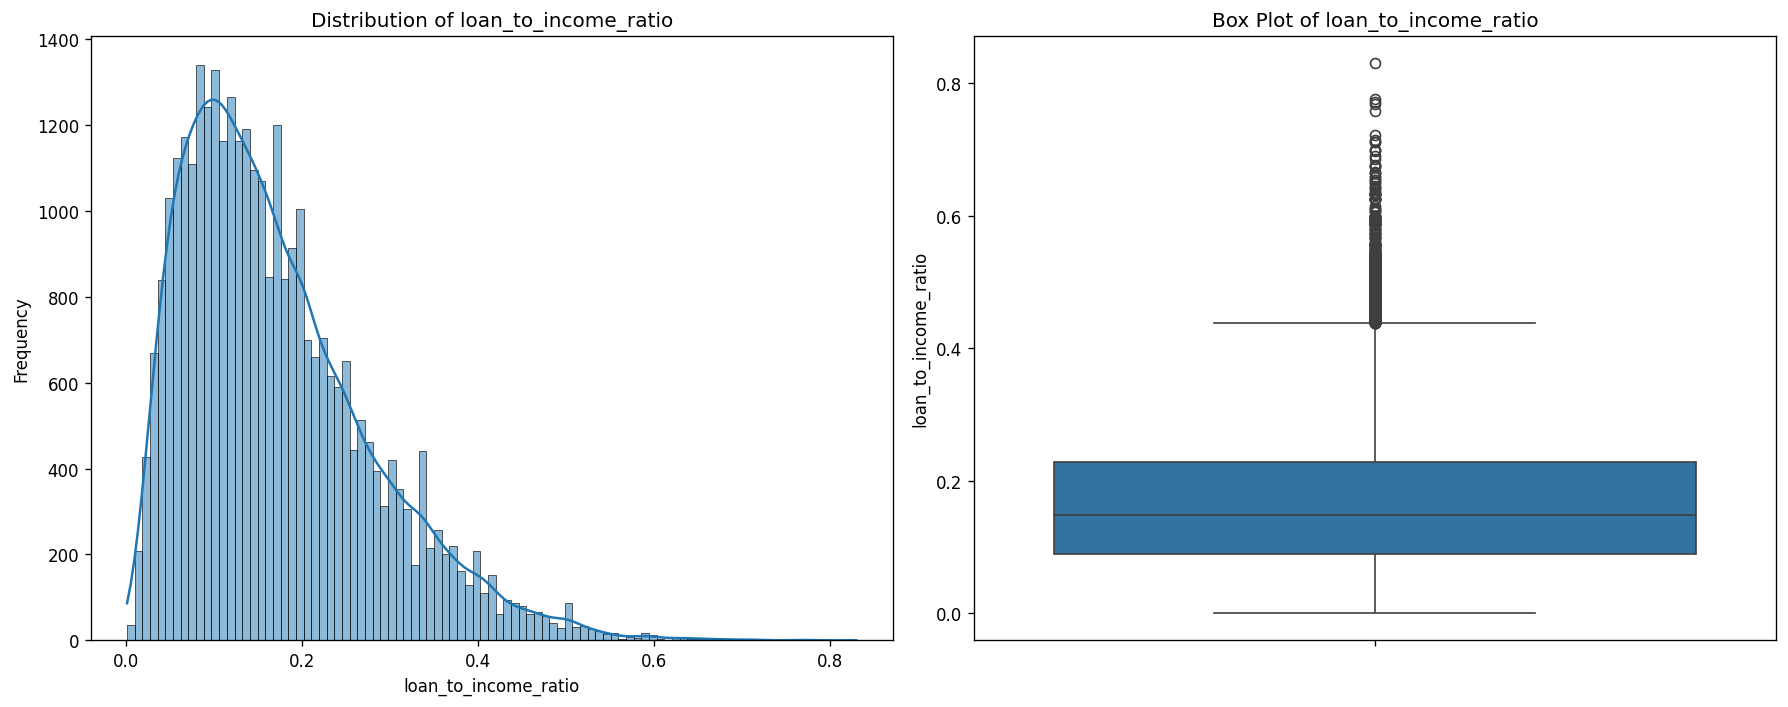

In [39]:
plt.figure(figsize=(15, 6))

# Histogram for loan_to_income_ratio
plt.subplot(1, 2, 1)
sns.histplot(df['loan_to_income_ratio'], kde=True)
plt.title('Distribution of loan_to_income_ratio')
plt.xlabel('loan_to_income_ratio')
plt.ylabel('Frequency')

# Box plot for loan_to_income_ratio
plt.subplot(1, 2, 2)
sns.boxplot(y=df['loan_to_income_ratio'])
plt.title('Box Plot of loan_to_income_ratio')
plt.ylabel('loan_to_income_ratio')

plt.tight_layout()
plt.show()

- Hai biến gần như đồng nhất.
- Median 15% — đa số người vay ở mức kiểm soát được. Tuy nhiên phần đuôi phải rất đáng lo: một số người vay tới 83% thu nhập — tức là gần như toàn bộ thu nhập chỉ đủ trả khoản vay này.
--> Cần loại bỏ 1 trong 2 biến trước khi đưa vào model để tránh multicollinearity.

### cb_person_cred_hist_length

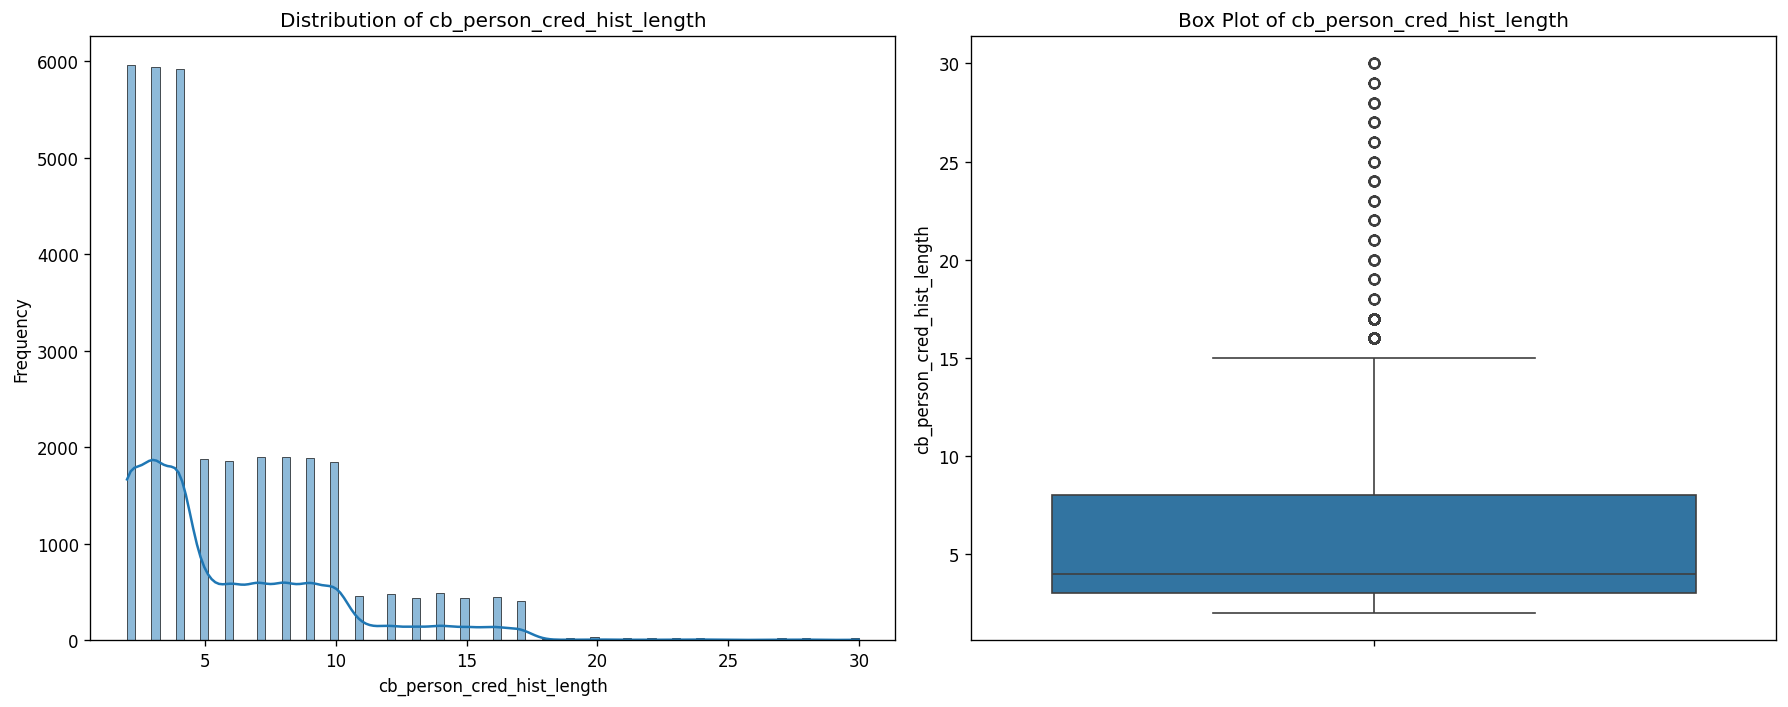

In [40]:
plt.figure(figsize=(15, 6))

# Histogram for cb_person_cred_hist_length
plt.subplot(1, 2, 1)
sns.histplot(df['cb_person_cred_hist_length'], kde=True)
plt.title('Distribution of cb_person_cred_hist_length')
plt.xlabel('cb_person_cred_hist_length')
plt.ylabel('Frequency')

# Box plot for cb_person_cred_hist_length
plt.subplot(1, 2, 2)
sns.boxplot(y=df['cb_person_cred_hist_length'])
plt.title('Box Plot of cb_person_cred_hist_length')
plt.ylabel('cb_person_cred_hist_length')

plt.tight_layout()
plt.show()

- Lịch sử tín dụng có median là 4 năm, nhất quán với đặc điểm người vay trẻ.
- Phân phối lệch phải: đa số có lịch sử tín dụng ngắn (2–8 năm), một số ít có lịch sử dài đến 30 năm.

### other_debt

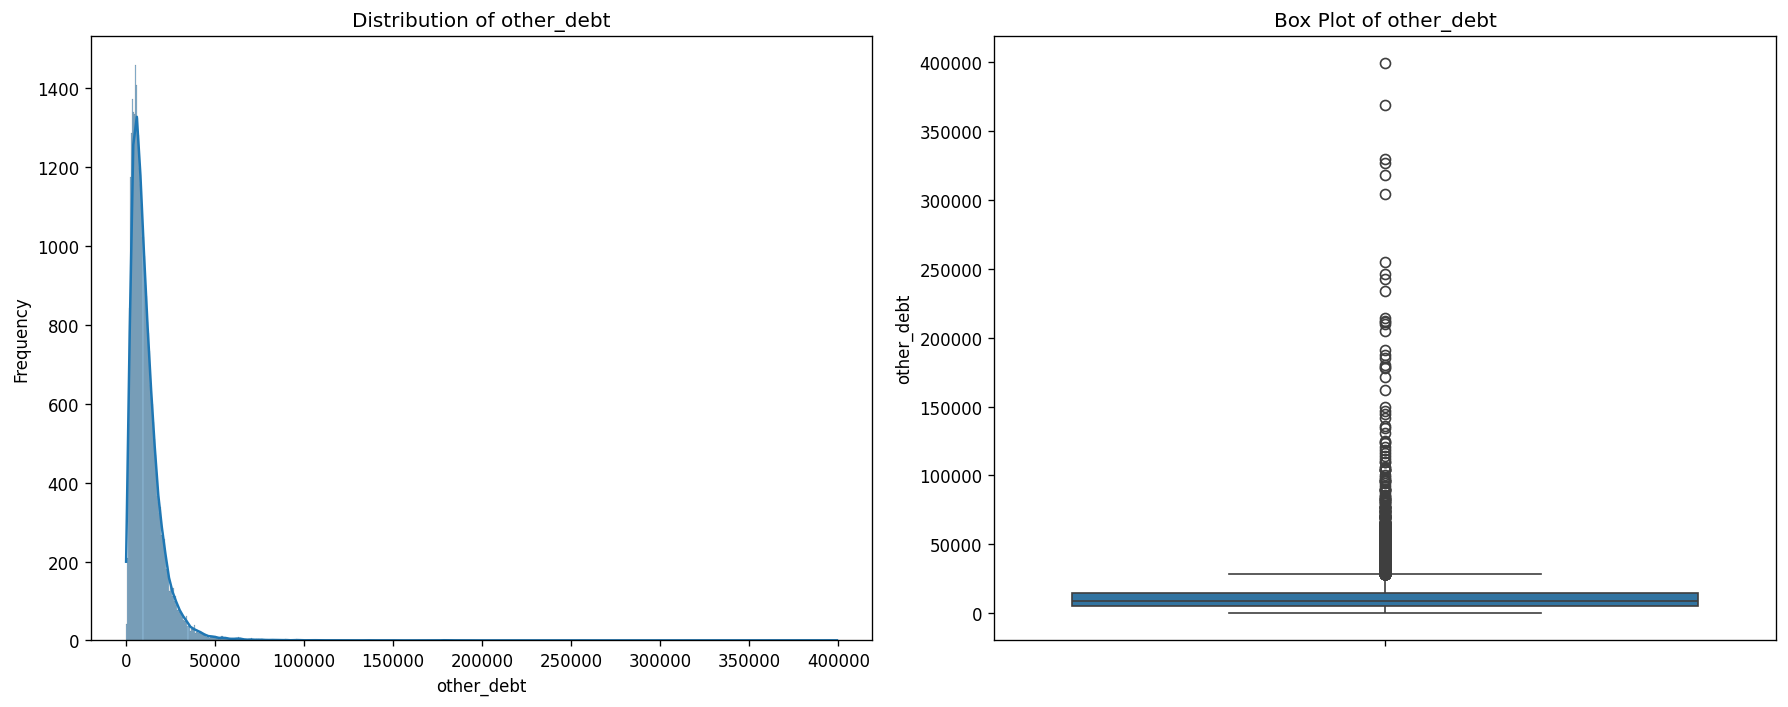

In [41]:
plt.figure(figsize=(15, 6))

# Histogram for other_debt
plt.subplot(1, 2, 1)
sns.histplot(df['other_debt'], kde=True)
plt.title('Distribution of other_debt')
plt.xlabel('other_debt')
plt.ylabel('Frequency')

# Box plot for other_debt
plt.subplot(1, 2, 2)
sns.boxplot(y=df['other_debt'])
plt.title('Box Plot of other_debt')
plt.ylabel('other_debt')

plt.tight_layout()
plt.show()

- Tổng nợ khác ngoài khoản vay đang xét có phân phối lệch phải cực mạnh, gần giống person_income.
- Median 8,976 nhưng max lên tới 399,126 — một số người có khoản nợ khổng lồ kéo mean (11,524) lên cao hơn median nhiều.

### debt_to_income_ratio

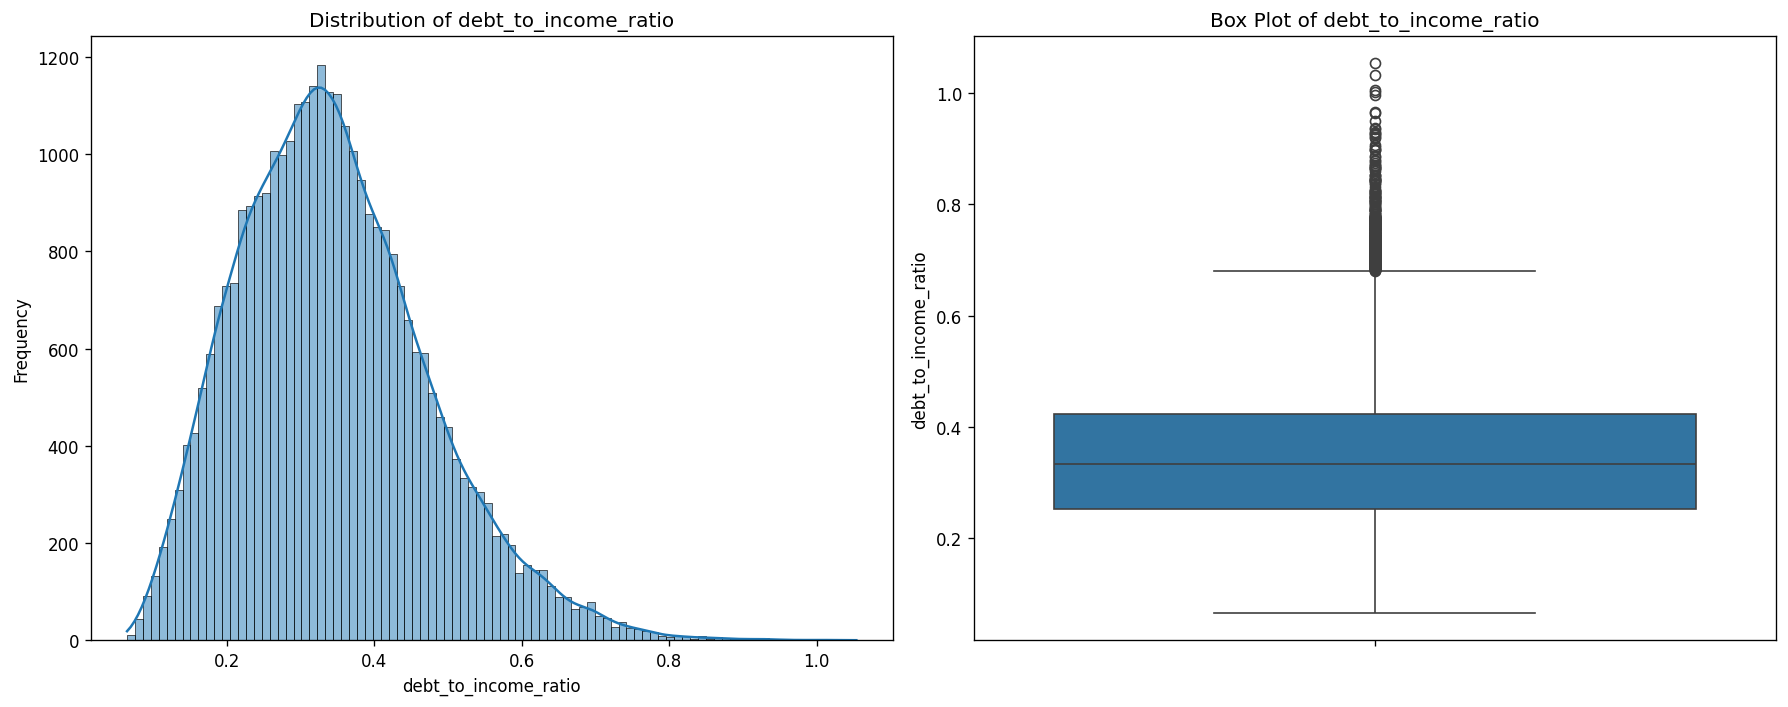

In [42]:
plt.figure(figsize=(15, 6))

# Histogram for debt_to_income_ratio
plt.subplot(1, 2, 1)
sns.histplot(df['debt_to_income_ratio'], kde=True)
plt.title('Distribution of debt_to_income_ratio')
plt.xlabel('debt_to_income_ratio')
plt.ylabel('Frequency')

# Box plot for debt_to_income_ratio
plt.subplot(1, 2, 2)
sns.boxplot(y=df['debt_to_income_ratio'])
plt.title('Box Plot of debt_to_income_ratio')
plt.ylabel('debt_to_income_ratio')

plt.tight_layout()
plt.show()

- Tổng gánh nặng nợ trên thu nhập có phân phối gần chuẩn — median 33%.
- Phần lớn người vay dùng 25–42% thu nhập để trả các loại nợ (IQR). Một số ít vượt 100% (max = 105%) — nghĩa là tổng nợ còn nhiều hơn thu nhập, tình trạng tài chính cực kỳ nguy hiểm.

### open_accounts

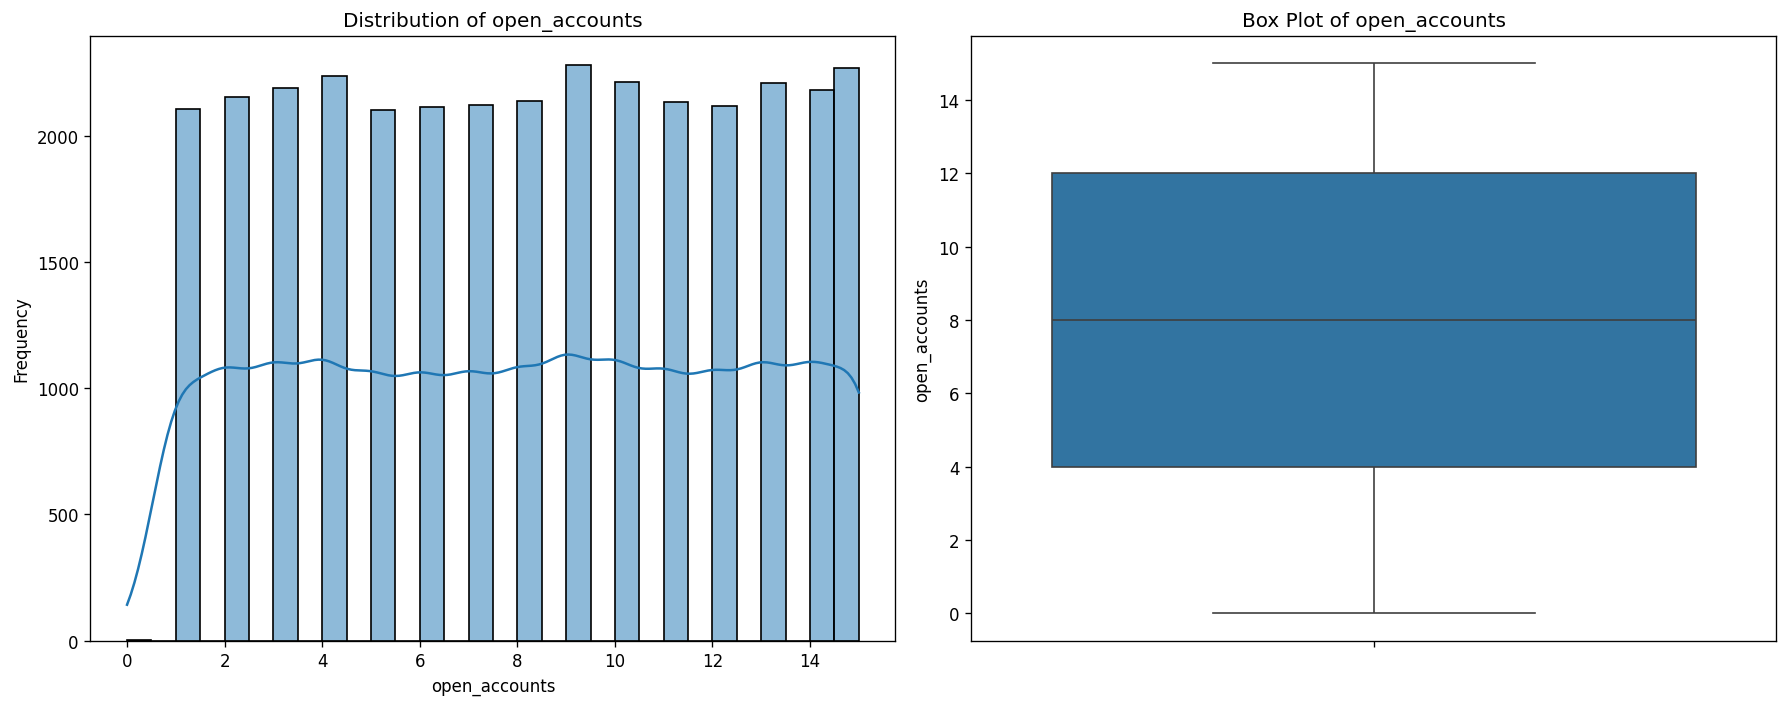

In [43]:
plt.figure(figsize=(15, 6))

# Histogram for open_accounts
plt.subplot(1, 2, 1)
sns.histplot(df['open_accounts'], kde=True)
plt.title('Distribution of open_accounts')
plt.xlabel('open_accounts')
plt.ylabel('Frequency')

# Box plot for open_accounts
plt.subplot(1, 2, 2)
sns.boxplot(y=df['open_accounts'])
plt.title('Box Plot of open_accounts')
plt.ylabel('open_accounts')

plt.tight_layout()
plt.show()

Số tài khoản tín dụng đang tương đương nhau, phần lớn từ 4-12 tài khoản

### credit_utilization_ratio

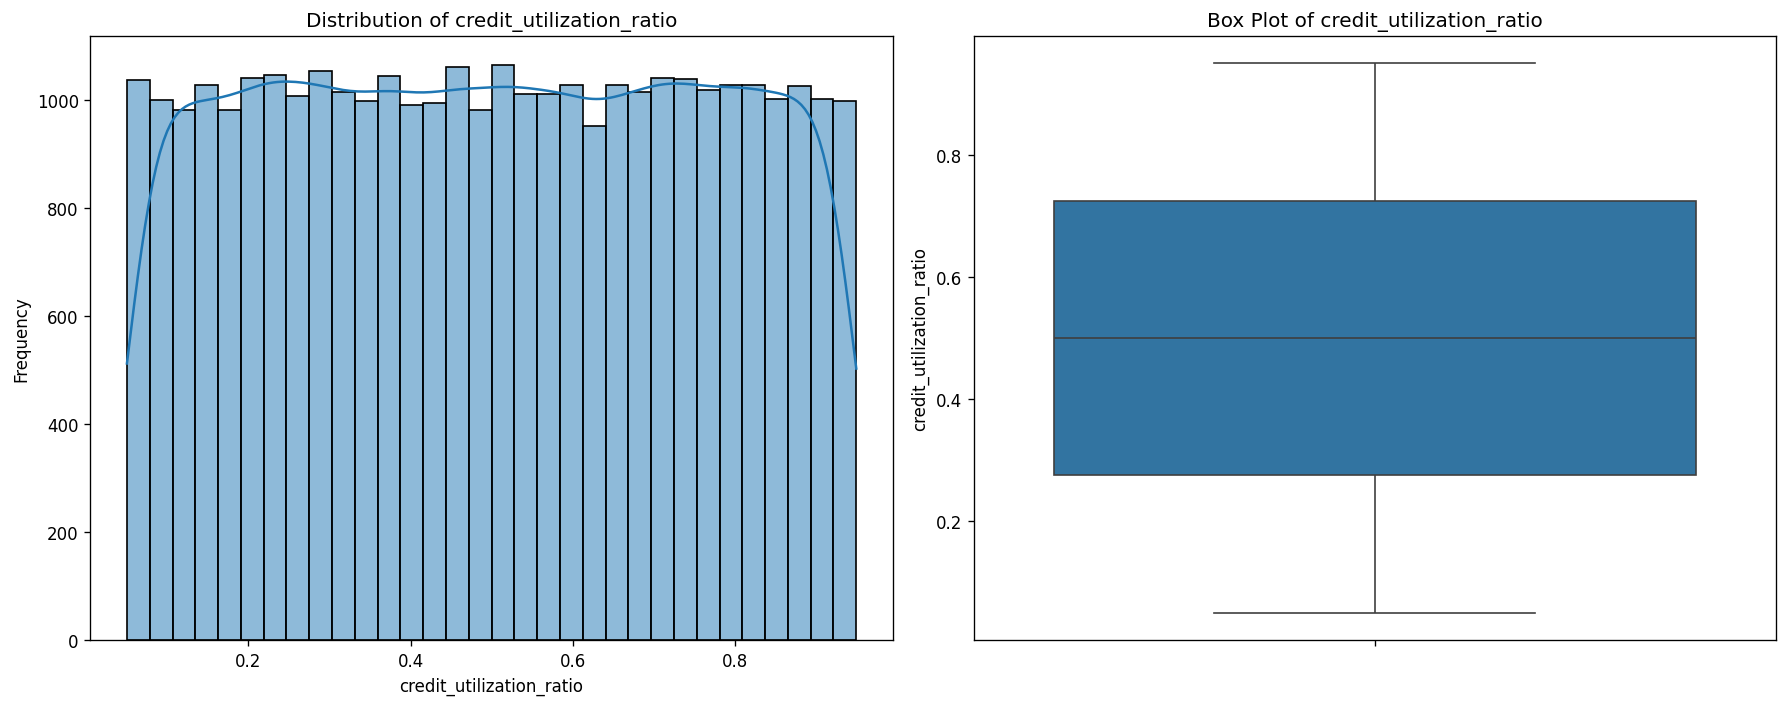

In [44]:
plt.figure(figsize=(15, 6))

# Histogram for credit_utilization_ratio
plt.subplot(1, 2, 1)
sns.histplot(df['credit_utilization_ratio'], kde=True)
plt.title('Distribution of credit_utilization_ratio')
plt.xlabel('credit_utilization_ratio')
plt.ylabel('Frequency')

# Box plot for credit_utilization_ratio
plt.subplot(1, 2, 2)
sns.boxplot(y=df['credit_utilization_ratio'])
plt.title('Box Plot of credit_utilization_ratio')
plt.ylabel('credit_utilization_ratio')

plt.tight_layout()
plt.show()

Biến đặc biệt nhất về phân phối — mean = median = 0.50, phân phối gần như đều hoàn toàn từ 0.05 đến 0.95. Người vay trải đều ở mọi mức sử dụng hạn mức tín dụng

### past_delinquencies

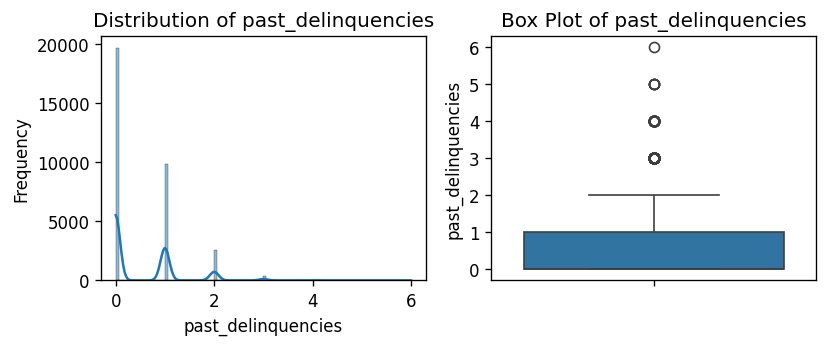

In [45]:

# Histogram for past_delinquencies
plt.subplot(1, 2, 1)
sns.histplot(df['past_delinquencies'], kde=True)
plt.title('Distribution of past_delinquencies')
plt.xlabel('past_delinquencies')
plt.ylabel('Frequency')

# Box plot for past_delinquencies
plt.subplot(1, 2, 2)
sns.boxplot(y=df['past_delinquencies'])
plt.title('Box Plot of past_delinquencies')
plt.ylabel('past_delinquencies')

plt.tight_layout()
plt.show()

- Số lần trễ hạn/vi phạm nghĩa vụ tín dụng trong quá khứ — phần lớn người vay có giá trị 0 (chưa từng trễ hạn).
- Phân phối lệch phải mạnh.

## Categorical

### person_home_ownership

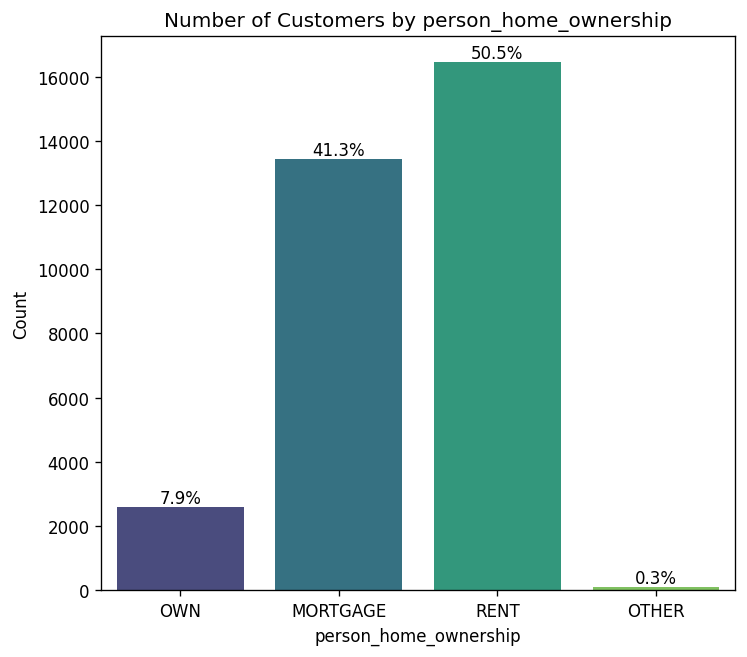

In [46]:
plt.figure(figsize=(15, 6))

# Count Plot: Customer distribution by person_home_ownership
plt.subplot(1, 2, 1)
sns.countplot(x='person_home_ownership', data=df, palette='viridis')
plt.title('Number of Customers by person_home_ownership')
plt.xlabel('person_home_ownership')
plt.ylabel('Count')

# Add percentages to the bars
total = len(df['person_home_ownership'])
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.gca().annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

- Hơn một nửa người vay đang thuê nhà — 50.5% RENT, 41.3% MORTGAGE, chỉ 7.9% OWN.
- Phân phối này nhất quán với đặc điểm người vay trẻ (median 26 tuổi) chưa tích lũy đủ tài sản. Tuy nhiên, nhóm RENT là nhóm rủi ro nhất và chiếm đa số —> đây là thách thức quản lý rủi ro lớn nhất của danh mục.

### loan_intent

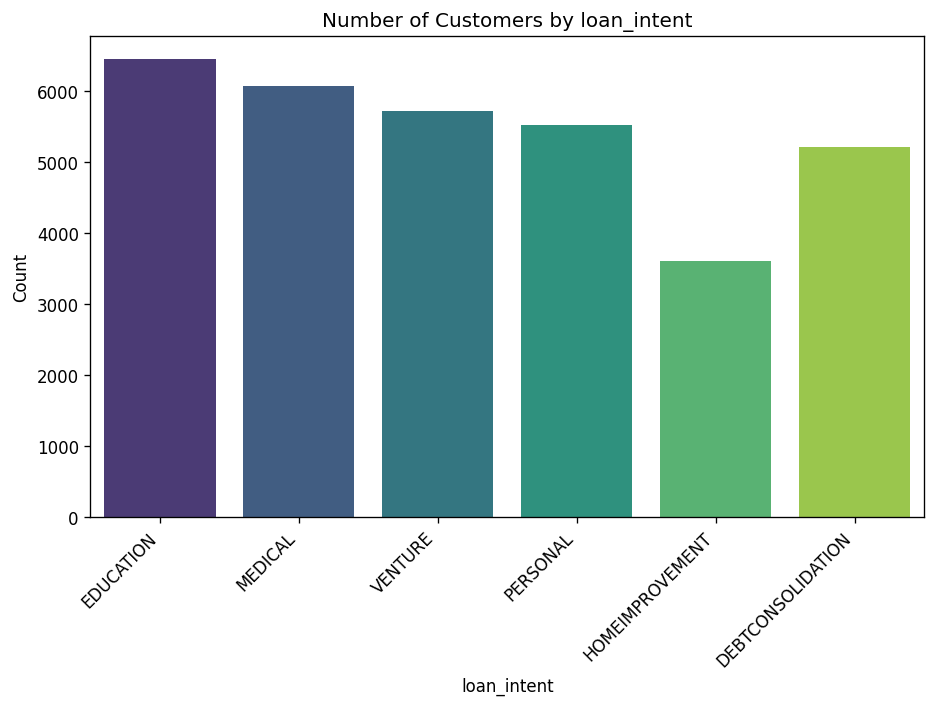

In [47]:
plt.figure(figsize=(15, 6))

# Count Plot: Customer distribution by loan_intent
plt.subplot(1, 2, 1)
sns.countplot(x='loan_intent', data=df, palette='viridis')
plt.title('Number of Customers by loan_intent')
plt.xlabel('loan_intent')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

6 mục đích vay phân phối tương đối đồng đều — không có nhóm nào chiếm ưu thế áp đảo. Education dẫn đầu, Home Improvement thấp nhất. Ngân hàng không tập trung vào một phân khúc vay cụ thể.

### loan_grade

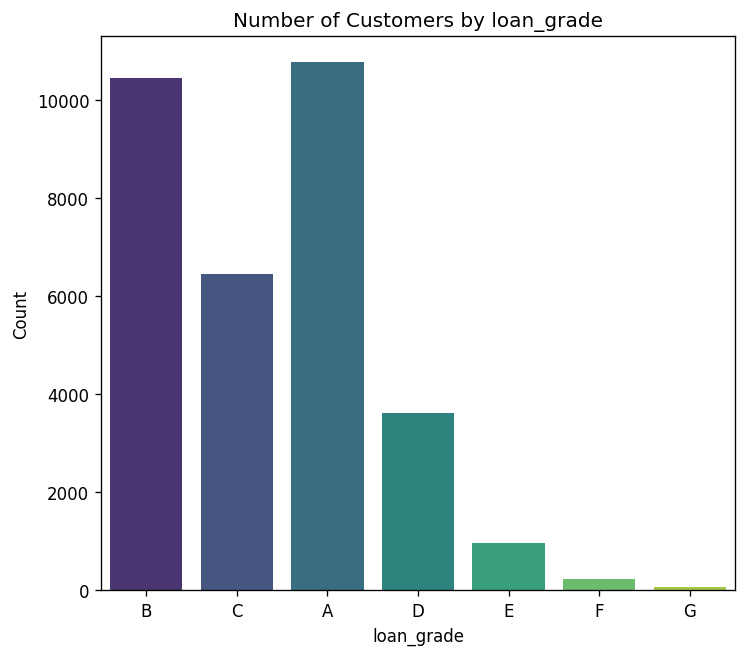

In [48]:
plt.figure(figsize=(15, 6))

# Count Plot: Customer distribution by loan_grade
plt.subplot(1, 2, 1)
sns.countplot(x='loan_grade', data=df, palette='viridis')
plt.title('Number of Customers by loan_grade')
plt.xlabel('loan_grade')
plt.ylabel('Count')
plt.show()

Phần lớn hồ sơ được phê duyệt là chất lượng tốt. Tuy nhiên, chính phần nhỏ hồ sơ Grade D–G lại là nguồn gốc của tổng nợ xấu — đây là sự tập trung rủi ro nguy hiểm.

### cb_person_default_on_file

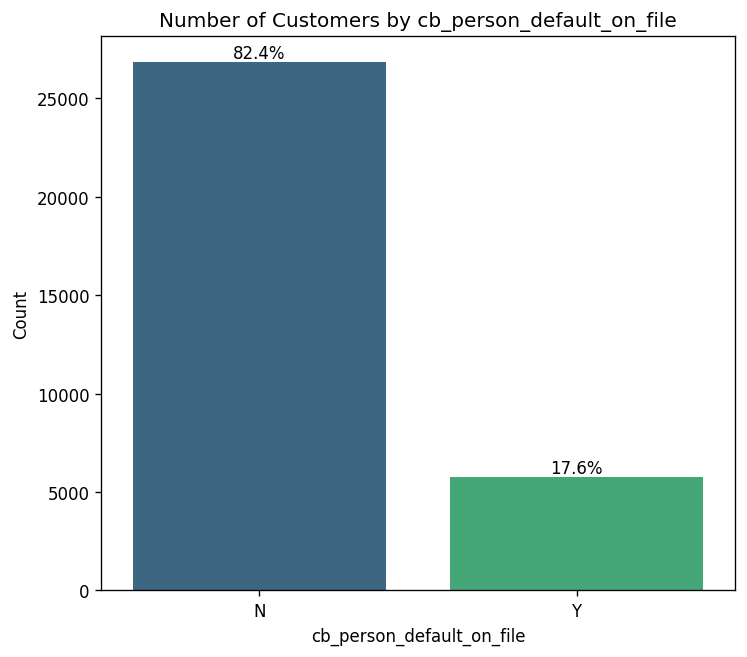

In [49]:
plt.figure(figsize=(15, 6))

# Count Plot: Customer distribution by cb_person_default_on_file
plt.subplot(1, 2, 1)
sns.countplot(x='cb_person_default_on_file', data=df, palette='viridis')
plt.title('Number of Customers by cb_person_default_on_file')
plt.xlabel('cb_person_default_on_file')
plt.ylabel('Count')

# Add percentages to the bars
total = len(df['cb_person_default_on_file'])
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.gca().annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

- 82.3% người vay không có lịch sử vỡ nợ (N), 17.7% đã từng vỡ nợ (Y).
- Tỷ lệ 17.7% cao hơn nhiều so với mức bình thường trong thực tế — trong dataset này ngân hàng vẫn đang duyệt khá nhiều hồ sơ có lịch sử xấu.

### loan_term_months

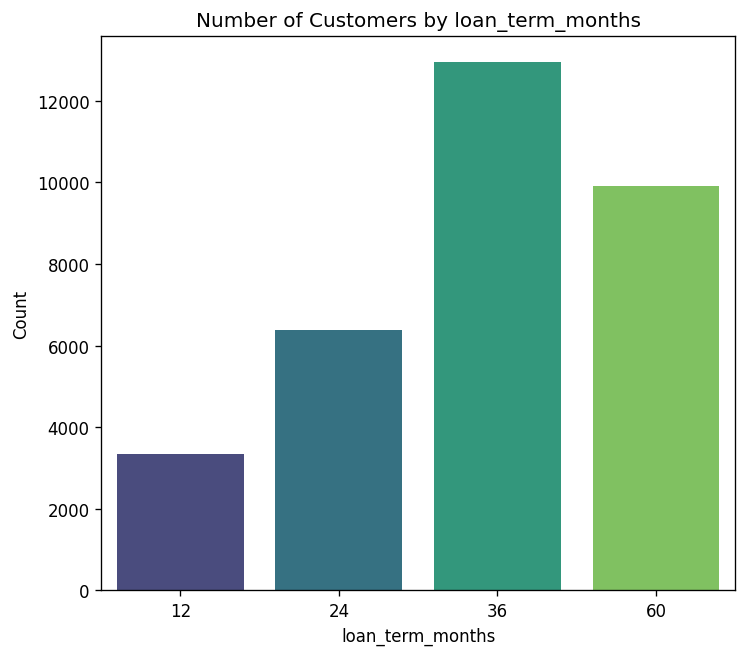

In [50]:
# Count Plot: Customer distribution by loan_term_months
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.countplot(x='loan_term_months', data=df, palette='viridis')
plt.title('Number of Customers by loan_term_months')
plt.xlabel('loan_term_months')
plt.ylabel('Count')
plt.show()

Phần lớn người vay chọn kỳ hạn trung đến dài (36–60 tháng) — điều này hợp lý vì kỳ hạn dài giúp giảm số tiền trả mỗi tháng, phù hợp với nhóm người trẻ thu nhập chưa cao.

### gender

Text(0, 0.5, 'Count')

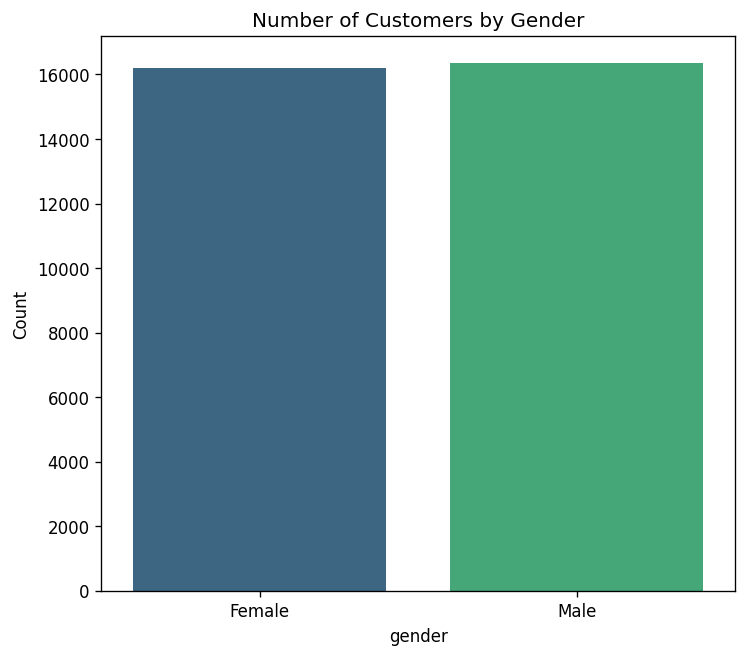

In [51]:
plt.figure(figsize=(15, 6))

# Count Plot: Customer distribution by country
plt.subplot(1, 2, 1)
sns.countplot(x='gender', data=df, palette='viridis')
plt.title('Number of Customers by Gender')
plt.xlabel('gender')
plt.ylabel('Count')

Nhận xét
- Tỷ lệ Male/Female gần cân bằng
- Ngân hàng không bị lệch về một nhóm giới tính cụ thể

### marital_status

Text(0, 0.5, 'Count')

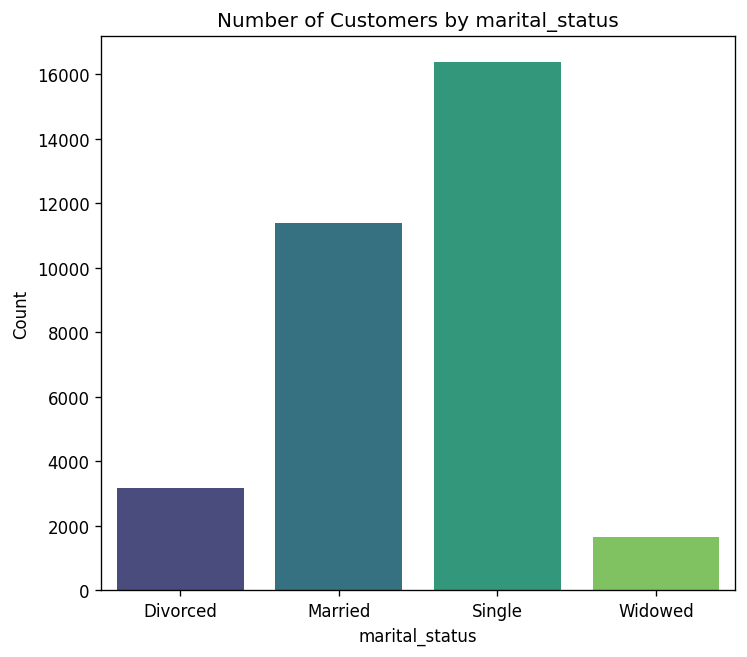

In [52]:
plt.figure(figsize=(15, 6))

# Count Plot: Customer distribution by marital_status
plt.subplot(1, 2, 1)
sns.countplot(x='marital_status', data=df, palette='viridis')
plt.title('Number of Customers by marital_status')
plt.xlabel('marital_status')
plt.ylabel('Count')

Giới tính và tình trạng hôn nhân: hai biến có phân phối gần cân bằng hoàn toàn — Single/Married chiếm phần lớn tổng hồ sơ, Male/Female xấp xỉ 50/50.

--> Dataset không bị sampling bias theo giới tính hay hôn nhân.

### education_level

Text(0, 0.5, 'Count')

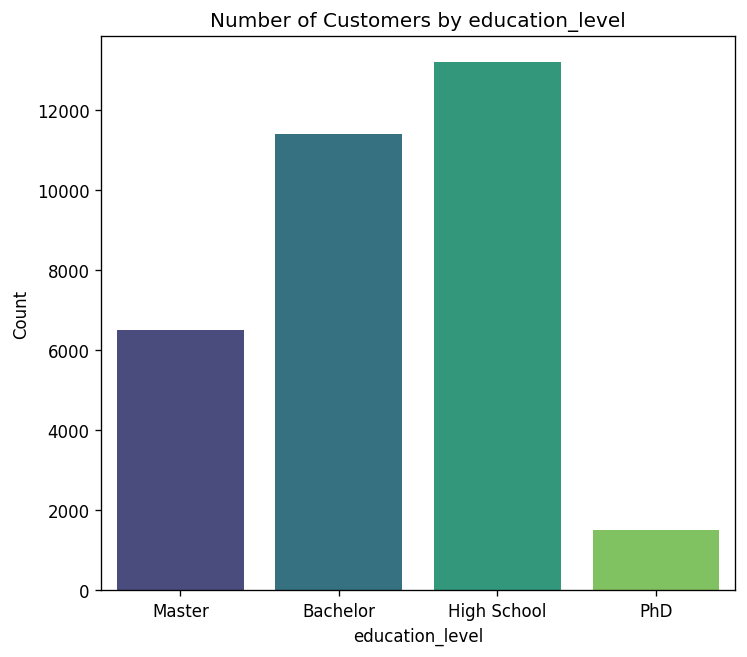

In [53]:
plt.figure(figsize=(15, 6))

# Count Plot: Customer distribution by education_level
plt.subplot(1, 2, 1)
sns.countplot(x='education_level', data=df, palette='viridis')
plt.title('Number of Customers by education_level')
plt.xlabel('education_level')
plt.ylabel('Count')

High School chiếm đa số, phân phối giảm dần theo học vấn, phản ánh cơ cấu dân số thực tế.

### country

Text(0, 0.5, 'Count')

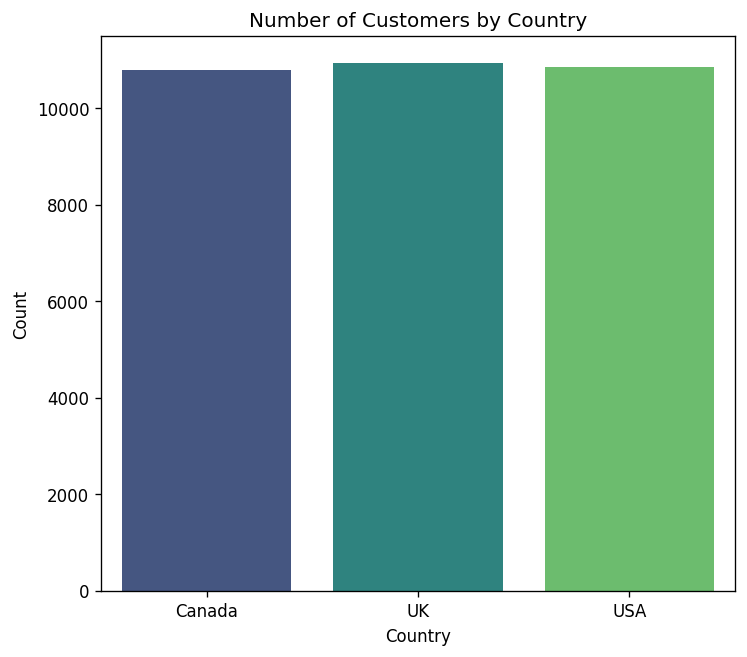

In [54]:
plt.figure(figsize=(15, 6))

# Count Plot: Customer distribution by country
plt.subplot(1, 2, 1)
sns.countplot(x='country', data=df, palette='viridis')
plt.title('Number of Customers by Country')
plt.xlabel('Country')
plt.ylabel('Count')



### state

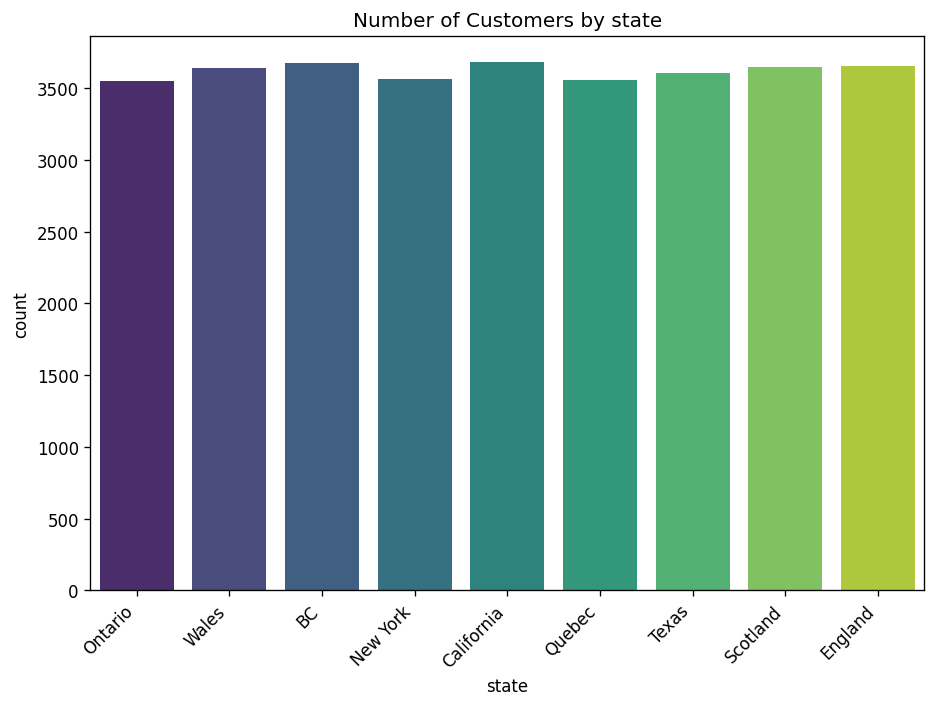

In [55]:
plt.figure(figsize=(15, 6))

# Count Plot: Customer distribution by state
plt.subplot(1, 2, 1)
sns.countplot(x='state', data=df, palette='viridis')
plt.title('Number of Customers by state')
plt.xlabel('state')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### city

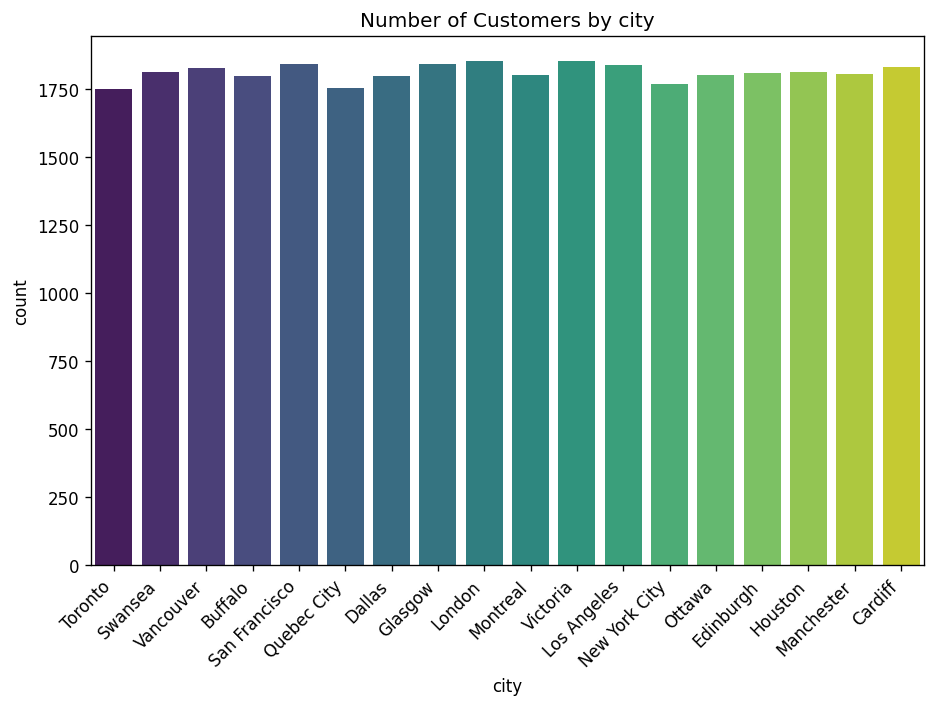

In [56]:
plt.figure(figsize=(15, 6))

# Count Plot: Customer distribution by city
plt.subplot(1, 2, 1)
sns.countplot(x='city', data=df, palette='viridis')
plt.title('Number of Customers by city')
plt.xlabel('city')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Toàn bộ 5 biến địa lý (country, state, city, city_latitude, city_longitude) có phân phối hoàn toàn đồng đều nhân tạo cho thấy đây là dataset tổng hợp —> các biến địa lý được gán ngẫu nhiên, không phản ánh pattern thực tế.

### employment_type

Text(0, 0.5, 'Count')

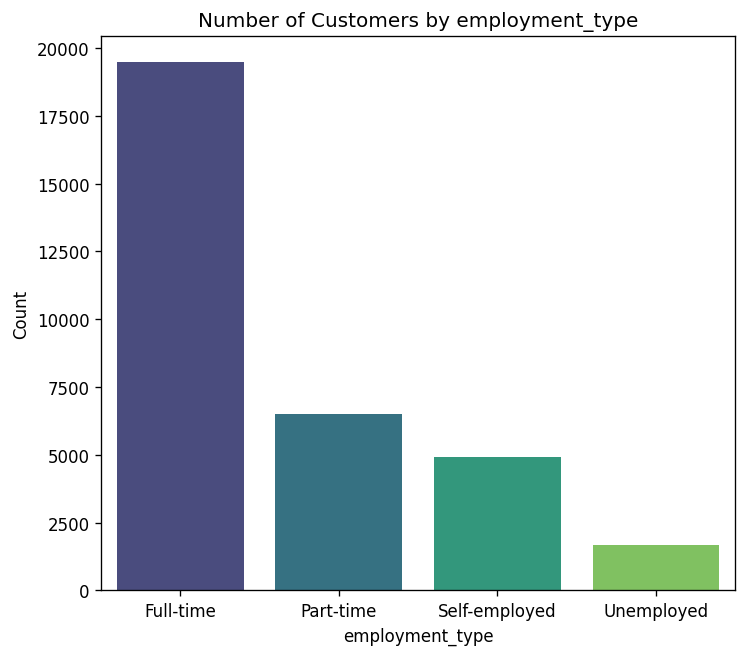

In [57]:
plt.figure(figsize=(15, 6))

# Count Plot: Customer distribution by employment_type
plt.subplot(1, 2, 1)
sns.countplot(x='employment_type', data=df, palette='viridis')
plt.title('Number of Customers by employment_type')
plt.xlabel('employment_type')
plt.ylabel('Count')


- Đa số là Full-time
- Điều đáng chú ý: một số khách hàng Unemployed nhưng vẫn được duyệt vay — ngân hàng có thể dựa vào các nguồn thu nhập khác (lương hưu, đầu tư).

## Insight tổng hợp từ Numerical và Categorical

Người vay điển hình là người trẻ (26 tuổi), thu nhập trung bình (55K), đang thuê nhà, mới đi làm được 4 năm, vay khoảng 8K với lãi suất 11%. Đây là nhóm người chưa tích lũy đủ tài sản nhưng có nhu cầu tài chính thực. Sự tập trung này tạo ra cả cơ hội lẫn rủi ro cho ngân hàng — nếu thẩm định tốt thì đây là tệp khách hàng có thể nuôi dưỡng lâu dài, nếu không thì tỷ lệ nợ xấu sẽ tiếp tục cao.

In [58]:
df.columns

Index(['client_ID', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length', 'gender',
       'marital_status', 'education_level', 'country', 'state', 'city',
       'city_latitude', 'city_longitude', 'employment_type',
       'loan_term_months', 'loan_to_income_ratio', 'other_debt',
       'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio',
       'past_delinquencies', 'emp_length_was_null'],
      dtype='object')

## Variable Value : loan_status

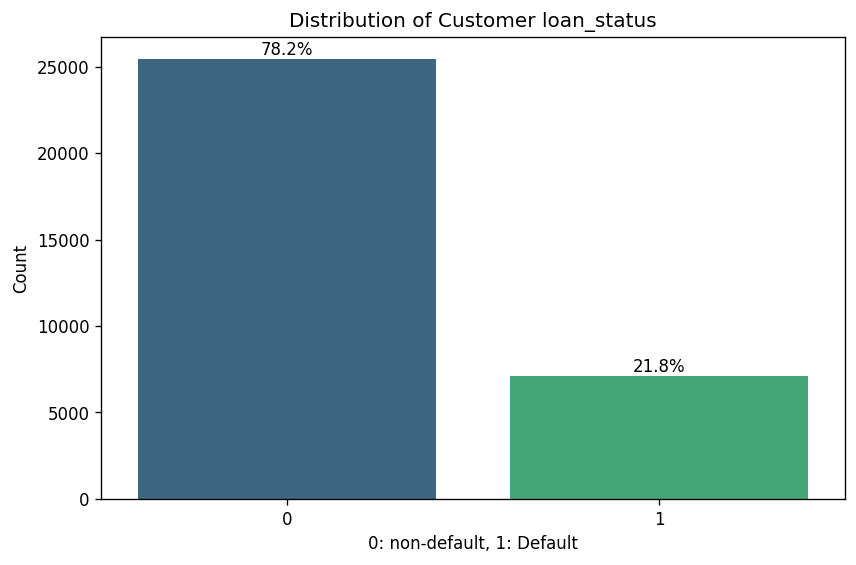

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Biểu đồ cho biến mục tiêu loan_status
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='loan_status', data=df, palette='viridis')
plt.title('Distribution of Customer loan_status')
plt.xlabel('0: non-default, 1: Default')
plt.ylabel('Count')

total = len(df['loan_status'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

## Bivariate Analysis

In [60]:
df.columns

Index(['client_ID', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length', 'gender',
       'marital_status', 'education_level', 'country', 'state', 'city',
       'city_latitude', 'city_longitude', 'employment_type',
       'loan_term_months', 'loan_to_income_ratio', 'other_debt',
       'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio',
       'past_delinquencies', 'emp_length_was_null'],
      dtype='object')

### loan_grade vs loan_status



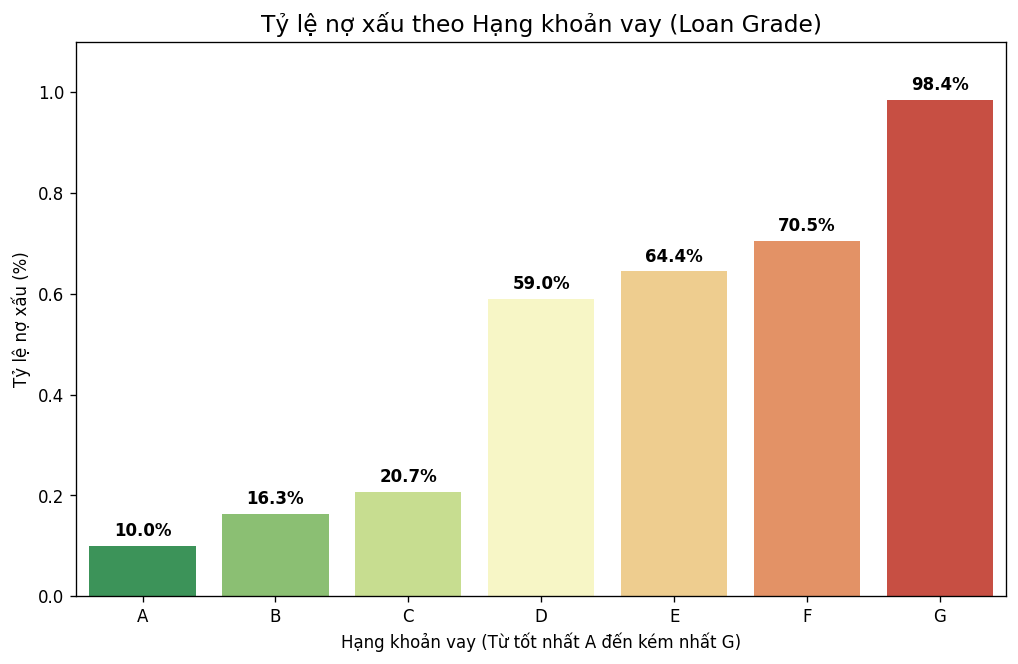

In [61]:
# 1. Chuẩn bị dữ liệu
risk_stats = df.groupby('loan_grade')['loan_status'].agg(['count', 'mean']).reset_index()
risk_stats.columns = ['loan_grade', 'Total_Customers', 'Default_Rate']
risk_stats = risk_stats.sort_values('loan_grade')

# 2. Vẽ biểu đồ Tỷ lệ nợ xấu (%) theo từng hạng
plt.figure(figsize=(10, 6))
# Sử dụng bảng màu từ Xanh (An toàn) sang Đỏ (Rủi ro)
sns.barplot(x='loan_grade', y='Default_Rate', data=risk_stats, palette='RdYlGn_r')

# Thêm con số % trên đầu mỗi cột để dễ nhìn
for i, row in risk_stats.iterrows():
    plt.text(i, row.Default_Rate + 0.02, f'{row.Default_Rate:.1%}', ha='center', fontweight='bold')

plt.title('Tỷ lệ nợ xấu theo Hạng khoản vay (Loan Grade)', fontsize=14)
plt.ylabel('Tỷ lệ nợ xấu (%)')
plt.xlabel('Hạng khoản vay (Từ tốt nhất A đến kém nhất G)')
plt.ylim(0, 1.1) # Để chừa chỗ cho label trên đầu cột
plt.show()

### loan_to_icome_ratio vs loan_status






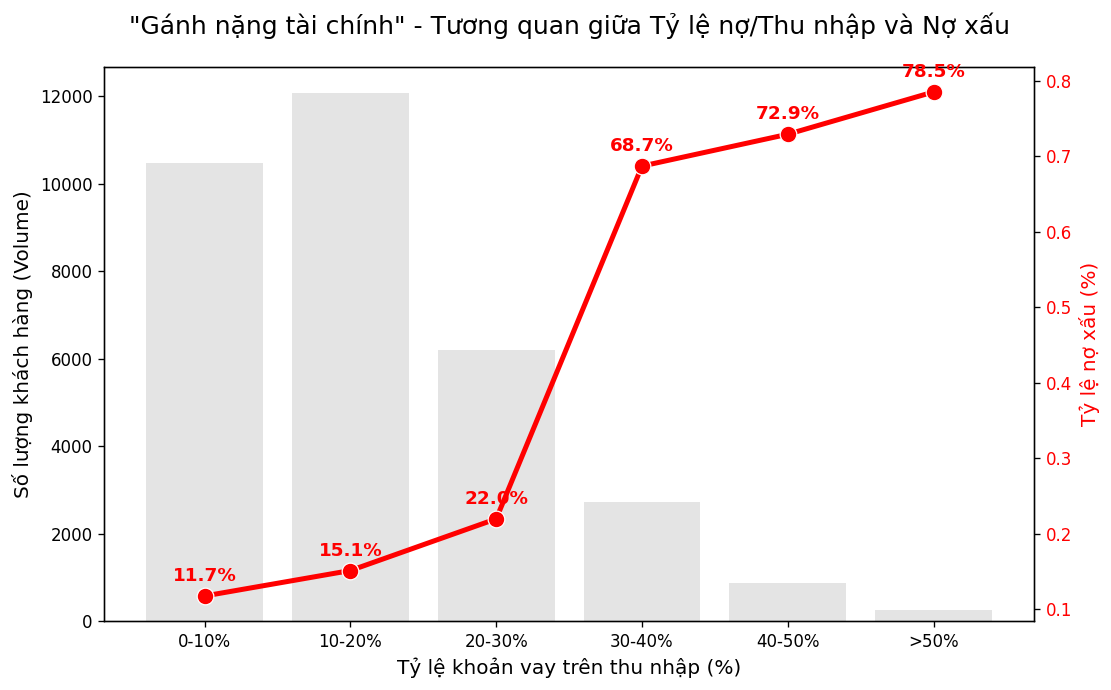

In [62]:
# 1. Chia nhóm Tỷ lệ vay/Thu nhập để tìm "Điểm gãy" (Tipping Point)
# Chúng ta chia theo các mốc quan trọng: 10%, 20%, 30%, 40%, 50%
df2 = df.copy()
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0]
labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '>50%']
df2['lpi_range'] = pd.cut(df2['loan_percent_income'], bins=bins, labels=labels)

# 2. Tính toán thống kê
lpi_stats = df2.groupby('lpi_range', observed=False)['loan_status'].agg(['count', 'mean']).reset_index()
lpi_stats.columns = ['lpi_range', 'Total_Customers', 'Default_Rate']

# 3. Vẽ biểu đồ kết hợp (Dual Axis Chart)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Vẽ cột cho Số lượng khách hàng (Volume)
sns.barplot(x='lpi_range', y='Total_Customers', data=lpi_stats, ax=ax1, color='lightgrey', alpha=0.6)
ax1.set_ylabel('Số lượng khách hàng (Volume)', fontsize=12)
ax1.set_xlabel('Tỷ lệ khoản vay trên thu nhập (%)', fontsize=12)

# Tạo trục thứ 2 cho Tỷ lệ nợ xấu
ax2 = ax1.twinx()
sns.lineplot(x='lpi_range', y='Default_Rate', data=lpi_stats, ax=ax2, marker='o', color='red', linewidth=3, markersize=10)
ax2.set_ylabel('Tỷ lệ nợ xấu (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Thêm nhãn số liệu cho đường Default Rate
for i, rate in enumerate(lpi_stats['Default_Rate']):
    ax2.text(i, rate + 0.02, f'{rate:.1%}', color='red', ha='center', fontweight='bold', fontsize=11)

plt.title('"Gánh nặng tài chính" - Tương quan giữa Tỷ lệ nợ/Thu nhập và Nợ xấu', fontsize=15, pad=20)
plt.show()

### person_home_ownership vs loan_status



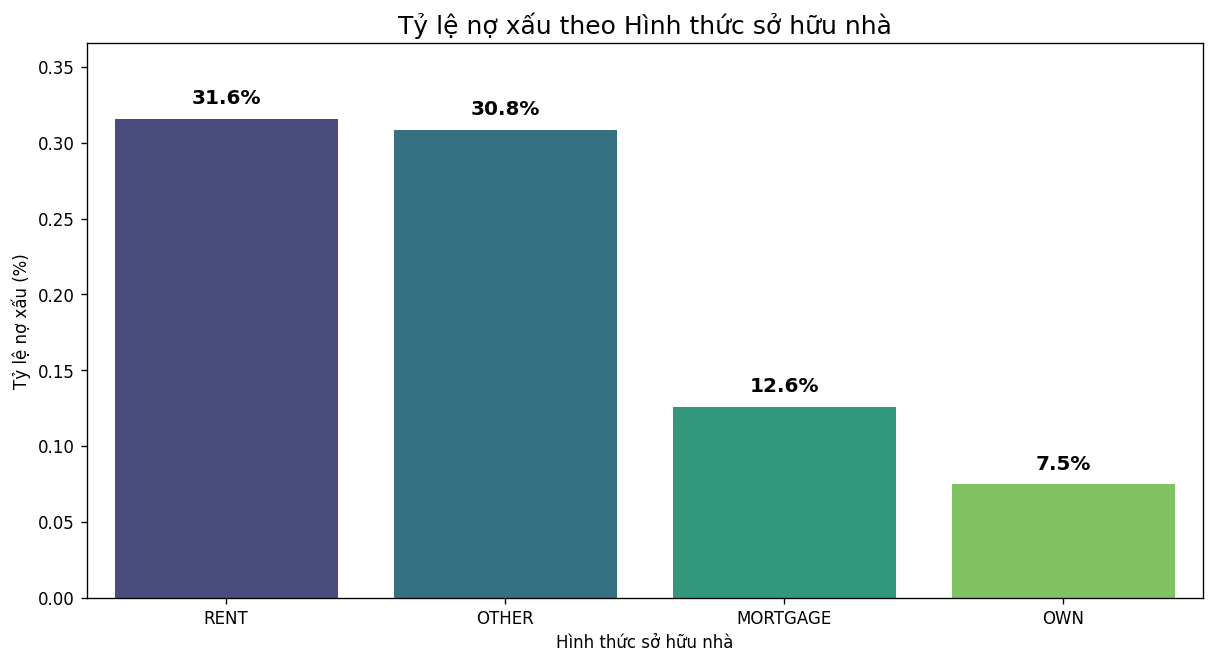

In [63]:

home_stats = df2.groupby('person_home_ownership')['loan_status'].agg(['count', 'mean']).reset_index()
home_stats.columns = ['Home_Ownership', 'Total_Customers', 'Default_Rate']
home_stats = home_stats.sort_values('Default_Rate', ascending=False)

# 2. Vẽ biểu đồ Bar Chart cho Default Rate
plt.figure(figsize=(12, 6))
sns.barplot(x='Home_Ownership', y='Default_Rate', data=home_stats, palette='viridis')

# Thêm nhãn %
for i, rate in enumerate(home_stats['Default_Rate']):
    plt.text(i, rate + 0.01, f'{rate:.1%}', ha='center', fontweight='bold', fontsize=12)

plt.title('Tỷ lệ nợ xấu theo Hình thức sở hữu nhà', fontsize=15)
plt.ylabel('Tỷ lệ nợ xấu (%)')
plt.xlabel('Hình thức sở hữu nhà')
plt.ylim(0, max(home_stats['Default_Rate']) + 0.05)
plt.show()


### cb_person_default_on_file vs loan_status

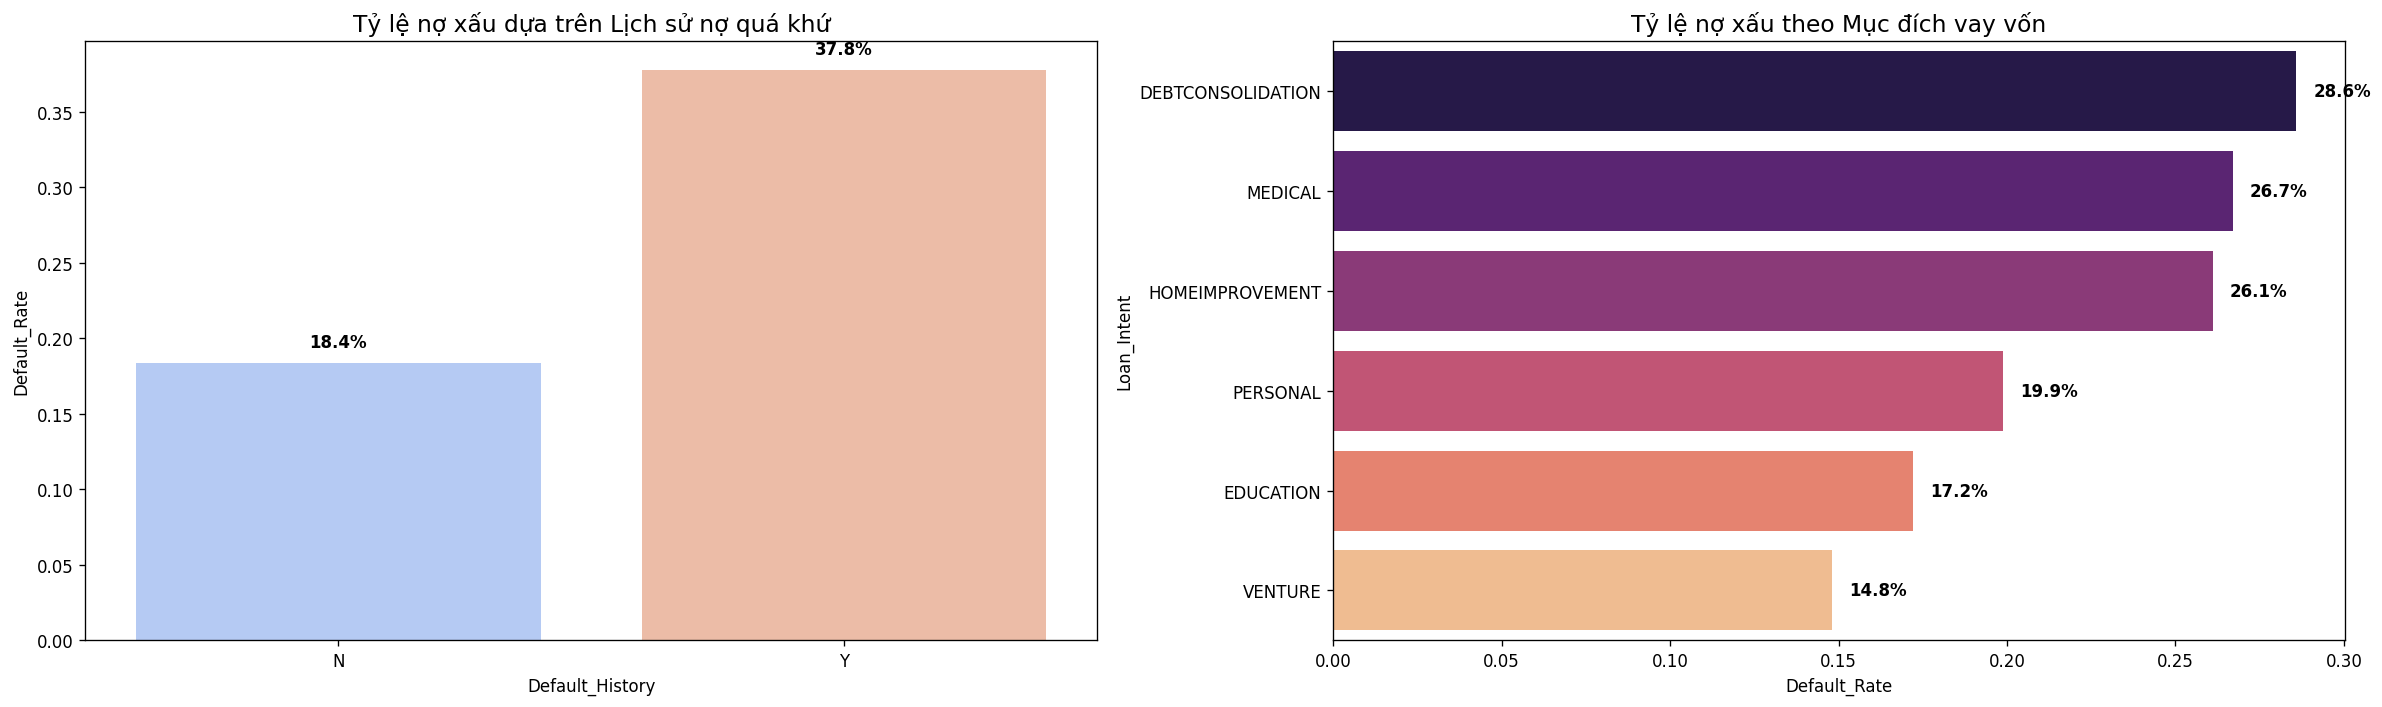

In [64]:
# 1. Phân tích theo Lịch sử nợ xấu (Default History)
hist_stats = df2.groupby('cb_person_default_on_file')['loan_status'].agg(['count', 'mean']).reset_index()
hist_stats.columns = ['Default_History', 'Total_Customers', 'Default_Rate']

# 2. Phân tích theo Mục đích vay (Loan Intent)
intent_stats = df2.groupby('loan_intent')['loan_status'].agg(['count', 'mean']).reset_index()
intent_stats.columns = ['Loan_Intent', 'Total_Customers', 'Default_Rate']
intent_stats = intent_stats.sort_values('Default_Rate', ascending=False)

# 3. Vẽ biểu đồ so sánh (Subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Biểu đồ 4a: Lịch sử nợ xấu
sns.barplot(x='Default_History', y='Default_Rate', data=hist_stats, ax=ax1, palette='coolwarm')
ax1.set_title('Tỷ lệ nợ xấu dựa trên Lịch sử nợ quá khứ', fontsize=14)
for i, rate in enumerate(hist_stats['Default_Rate']):
    ax1.text(i, rate + 0.01, f'{rate:.1%}', ha='center', fontweight='bold')

# Biểu đồ 4b: Mục đích vay
sns.barplot(x='Default_Rate', y='Loan_Intent', data=intent_stats, ax=ax2, palette='magma')
ax2.set_title('Tỷ lệ nợ xấu theo Mục đích vay vốn', fontsize=14)
for i, rate in enumerate(intent_stats['Default_Rate']):
    ax2.text(rate + 0.005, i, f'{rate:.1%}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

* Lịch sử tín dụng: "Những khách hàng từng có nợ xấu ghi nhận trên hệ thống (Default History = Y) có tỷ lệ vỡ nợ lên tới 37.6%. Quá khứ thực sự là tấm gương phản chiếu chính xác nhất rủi ro tương lai."

* Mục đích vay: "Đáng chú ý nhất là nhóm vay để Đảo nợ (Debt Consolidation) và Y tế (Medical) có tỷ lệ rủi ro cao nhất (xấp xỉ 26-28%). Ngược lại, những khoản vay cho Đầu tư mạo hiểm (Venture) lại có tỷ lệ hoàn trả tốt nhất. Điều này cho thấy khách hàng vay để giải quyết khó khăn tài chính hiện tại thường dễ vỡ nợ hơn khách hàng vay để phát triển tương lai."

### Bivariate Categorical

In [65]:
COLOR_0 = '#4A90D9'   # xanh = không default
COLOR_1 = '#E74C3C'   # đỏ   = default
AVG_DEFAULT = df2['loan_status'].mean()

d0 = df2[df2['loan_status'] == 0]
d1 = df2[df2['loan_status'] == 1]

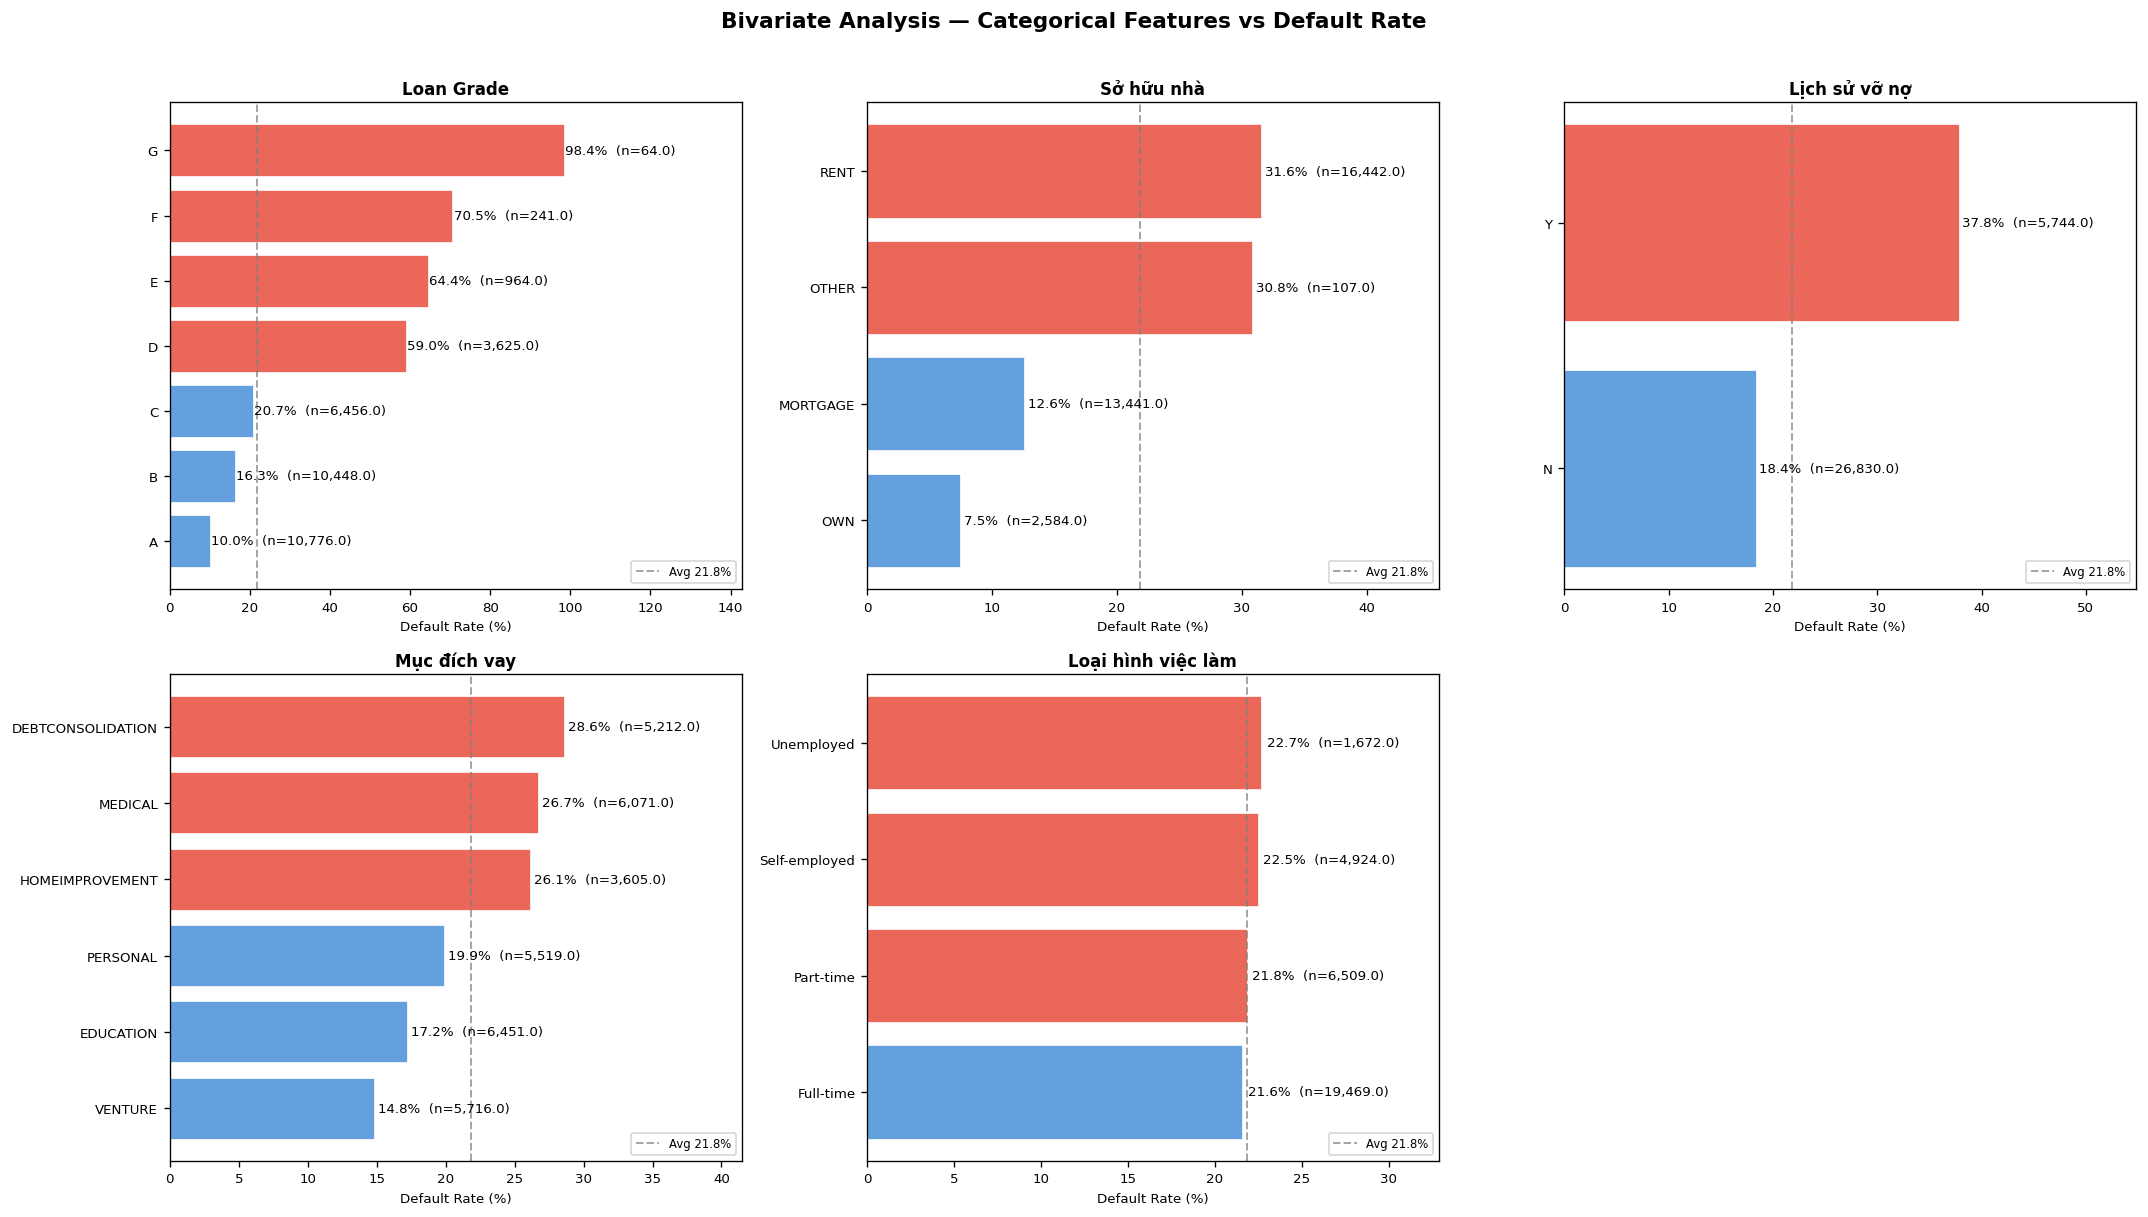

In [66]:
# ══════════════════════════════════════════════════════════════════════
#  CATEGORICAL VARIABLES vs LOAN_STATUS
# ══════════════════════════════════════════════════════════════════════
cat_info = [
    ('loan_grade',               'Loan Grade',          None),
    ('person_home_ownership',    'Sở hữu nhà',          None),
    ('cb_person_default_on_file','Lịch sử vỡ nợ',       None),
    ('loan_intent',              'Mục đích vay',        None),
    ('employment_type',          'Loại hình việc làm',  None),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Bivariate Analysis — Categorical Features vs Default Rate",
             fontsize=13, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, (col, title, _) in enumerate(cat_info):
    ax = axes[i]
    grp = df2.groupby(col)['loan_status'].agg(
        default_rate='mean', count='count'
    ).sort_values('default_rate', ascending=True)

    colors = [COLOR_1 if r > AVG_DEFAULT else COLOR_0
              for r in grp['default_rate']]
    bars = ax.barh(grp.index.astype(str), grp['default_rate'] * 100,
                   color=colors, edgecolor='white', linewidth=0.5, alpha=0.85)

    # Đường trung bình
    ax.axvline(AVG_DEFAULT * 100, color='gray', linestyle='--',
               linewidth=1.2, alpha=0.7, label=f'Avg {AVG_DEFAULT:.1%}')

    # Ghi % và count
    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f"{row['default_rate']:.1%}  (n={row['count']:,})",
                va='center', fontsize=8)

    ax.set_title(title, fontsize=10, fontweight='bold', pad=5)
    ax.set_xlabel('Default Rate (%)', fontsize=8)
    ax.set_xlim(0, grp['default_rate'].max() * 100 * 1.45)
    ax.legend(fontsize=7, loc='lower right')
    ax.tick_params(labelsize=8)

# Remove the empty subplot (since we have 5 charts for a 3x2 grid)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

- Loan grade: các hạng D,E,F,G mang lại rủi ro cao, đặc biệt người đi vay thuộc hạng G gần như chắc chắn sẽ không trả được nợ
- Sở hữu nhà: Đa số khách hàng vỡ nợ nằm ở nhóm RENT (Đi thuê nhà). Tỷ lệ nợ xấu ở nhóm này (~31%) cao gấp nhiều lần so với nhóm có nhà riêng.
- Lịch sử vỡ nợ: Một khách hàng đã từng bùng nợ trong quá khứ, thì xác suất họ tái bùng nợ hiện tại là cực kỳ cao, lên tới gần 40%.
- Mục đích vay: tập trung vào MEDICAL (Y tế) và DEBT CONSOLIDATION (Đảo nợ), cho thấy khi khách hàng vay tiền để trả nợ cũ hoặc chữa bệnh, họ vốn đã rơi vào tình trạng kiệt quệ tài chính trước khi tiếp cận khoản vay mới.
- Loại hình việc làm: tỷ lệ ở các nhóm khá giống nhau nên không có đặc điểm nào nổi bật ở đây

### Bivariate Numerical

Vẽ Chart 2 — Numerical bivariate...


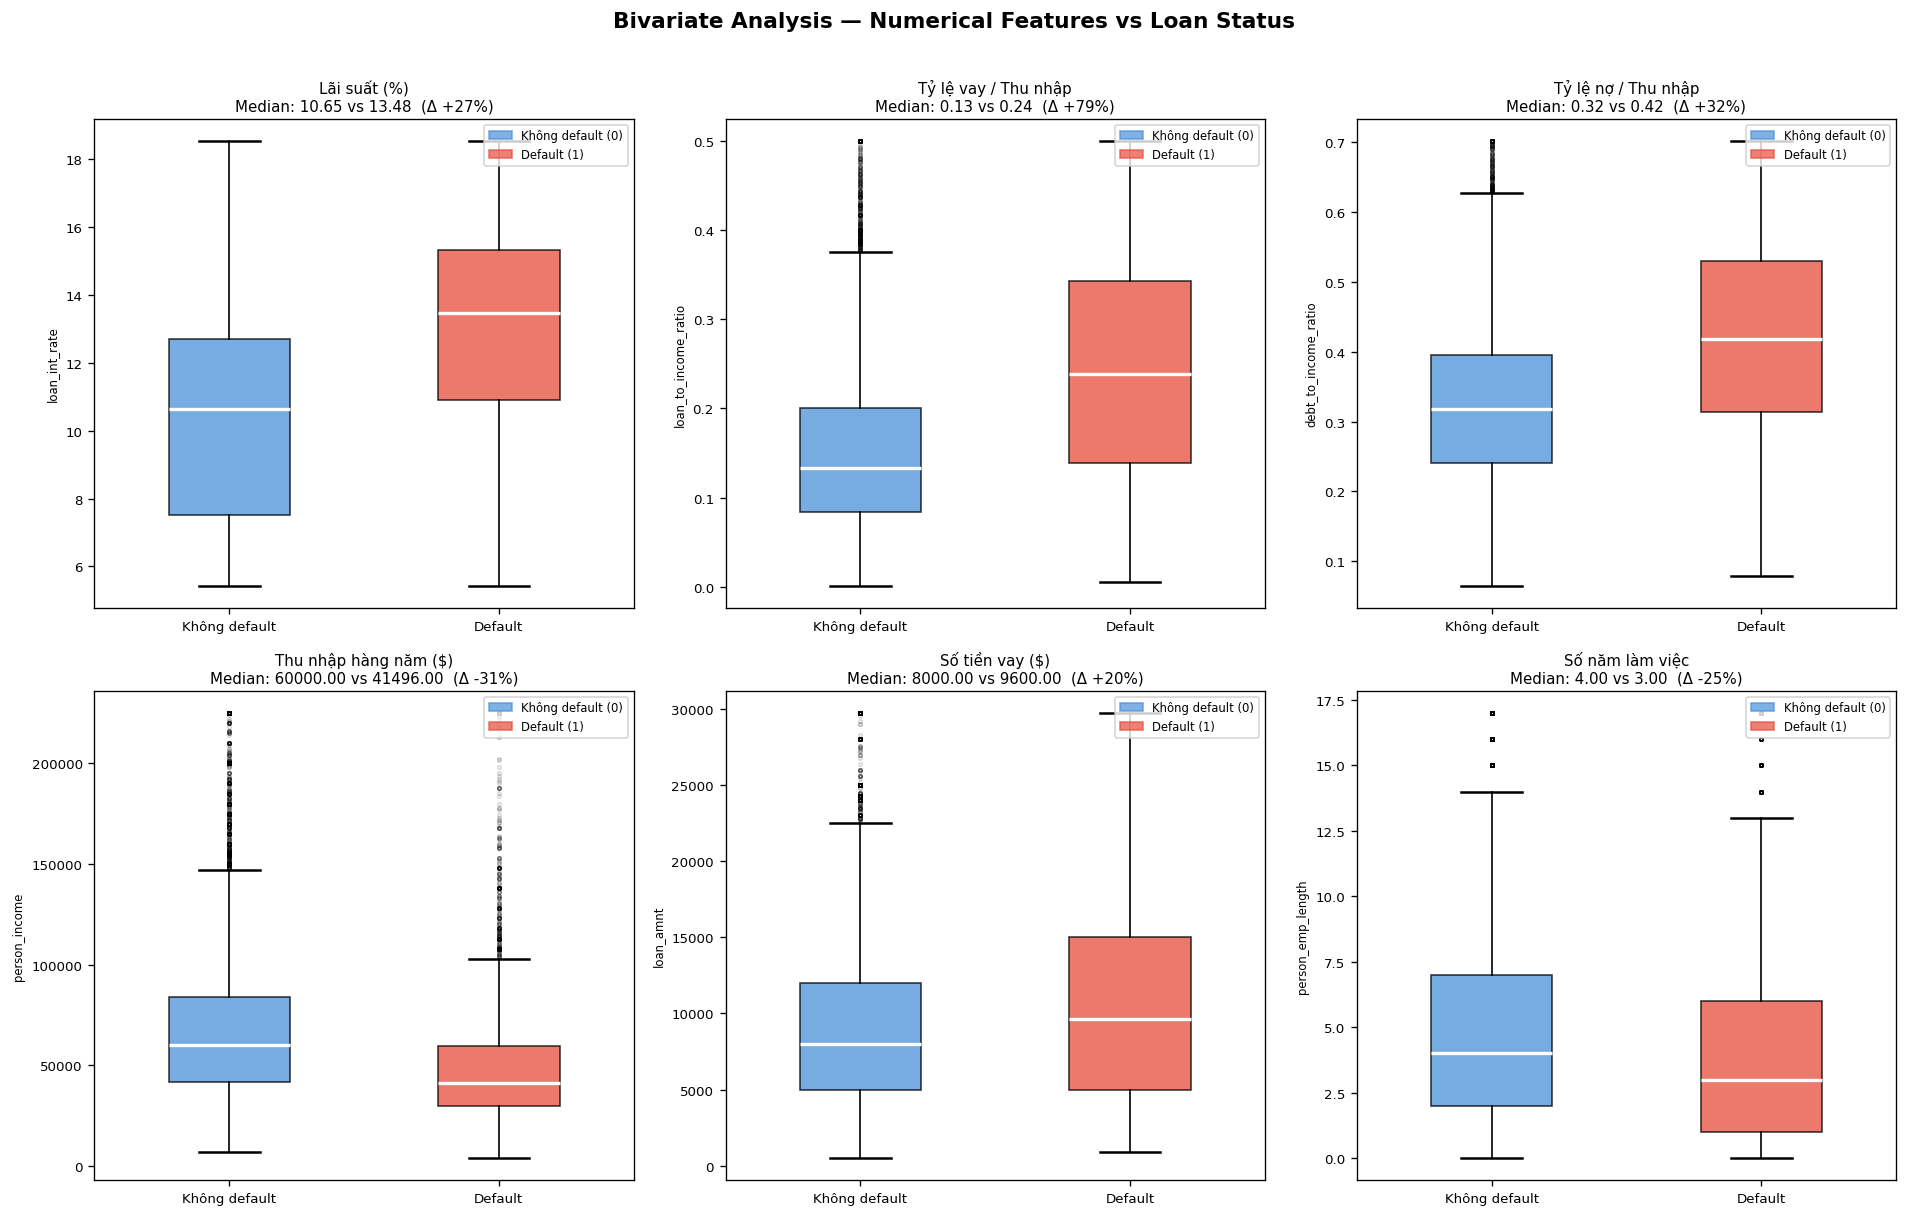

In [67]:
#  NUMERICAL VARIABLES vs LOAN_STATUS
#  Box plots cạnh nhau + KDE overlay cho top features
# ══════════════════════════════════════════════════════════════════════
import matplotlib.patches as mpatches
print("Vẽ Chart 2 — Numerical bivariate...")

num_top = [
    ('loan_int_rate',        'Lãi suất (%)'),
    ('loan_to_income_ratio', 'Tỷ lệ vay / Thu nhập'),
    ('debt_to_income_ratio', 'Tỷ lệ nợ / Thu nhập'),
    ('person_income',        'Thu nhập hàng năm ($)'),
    ('loan_amnt',            'Số tiền vay ($)'),
    ('person_emp_length',    'Số năm làm việc'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Bivariate Analysis — Numerical Features vs Loan Status",
             fontsize=13, fontweight='bold', y=1.01)
axes = axes.flatten()

patch0 = mpatches.Patch(color=COLOR_0, alpha=0.7, label='Không default (0)')
patch1 = mpatches.Patch(color=COLOR_1, alpha=0.7, label='Default (1)')

for i, (col, title) in enumerate(num_top):
    ax = axes[i]

    # Clip outliers để nhìn rõ hơn (99th percentile)
    upper = df2[col].quantile(0.99)
    data0 = d0[col].clip(upper=upper)
    data1 = d1[col].clip(upper=upper)

    bp = ax.boxplot(
        [data0, data1],
        labels=['Không default', 'Default'],
        patch_artist=True,
        notch=False,
        widths=0.45,
        boxprops=dict(linewidth=1),
        medianprops=dict(linewidth=2, color='white'),
        whiskerprops=dict(linewidth=1),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=2, alpha=0.15)
    )
    bp['boxes'][0].set_facecolor(COLOR_0)
    bp['boxes'][0].set_alpha(0.75)
    bp['boxes'][1].set_facecolor(COLOR_1)
    bp['boxes'][1].set_alpha(0.75)

    med0 = data0.median()
    med1 = data1.median()
    diff_pct = (med1 - med0) / med0 * 100 if med0 != 0 else 0

    ax.set_title(f"{title}\nMedian: {med0:.2f} vs {med1:.2f}  "
                 f"(Δ {diff_pct:+.0f}%)",
                 fontsize=9, pad=5)
    ax.tick_params(labelsize=8)
    ax.set_ylabel(col, fontsize=7)
    ax.legend(handles=[patch0, patch1], fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

- Lãi suất (loan_int_rate): Khách hàng vỡ nợ có xu hướng có lãi suất cao hơn đáng kể (median ~13.5% so với ~10.7% của nhóm không vỡ nợ).
- Tỷ lệ vay/Thu nhập (loan_to_income_ratio): Tỷ lệ này cao hơn ở nhóm vỡ nợ (median ~24% so với ~13% của nhóm không vỡ nợ). Khi tỷ lệ này vượt quá 30% thì rủi ro vỡ nợ tăng vọt.
- Tỷ lệ nợ/Thu nhập (debt_to_income_ratio): Tương tự, nhóm vỡ nợ có tổng gánh nặng nợ trên thu nhập cao hơn (median ~42% so với ~32%).
- Thu nhập hàng năm (person_income): Nhóm khách hàng vỡ nợ có thu nhập thấp hơn đáng kể (median ~41,000 so với ~60,000 so với ~60,000 của nhóm không vỡ nợ).
- Số tiền vay (loan_amnt): Nhóm vỡ nợ có xu hướng vay số tiền lớn hơn.
- Số năm làm việc (person_emp_length): Không có sự khác biệt rõ rệt về số năm làm việc giữa hai nhóm.

### Bivariate Heatmap

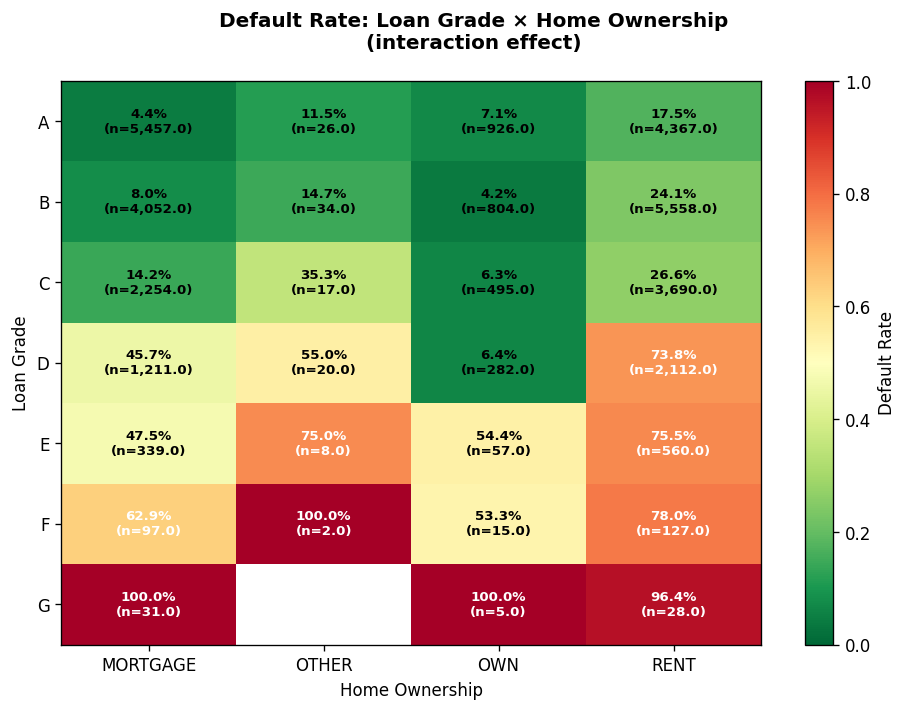

In [68]:
# HEATMAP: LOAN_GRADE x HOME_OWNERSHIP
# ══════════════════════════════════════════════════════════════════════

pivot = df2.groupby(['loan_grade', 'person_home_ownership'])['loan_status']\
          .mean().round(3).unstack()
pivot_count = df2.groupby(['loan_grade', 'person_home_ownership'])['loan_status']\
                .count().unstack()

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("Default Rate: Loan Grade × Home Ownership\n(interaction effect)",
             fontsize=12, fontweight='bold')

import matplotlib.colors as mcolors
cmap = plt.cm.RdYlGn_r
im = ax.imshow(pivot.values, cmap=cmap, aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Default Rate')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)
ax.set_xlabel('Home Ownership', fontsize=10)
ax.set_ylabel('Loan Grade', fontsize=10)

for r in range(pivot.shape[0]):
    for c in range(pivot.shape[1]):
        val = pivot.values[r, c]
        cnt = pivot_count.values[r, c]
        if not np.isnan(val):
            text_color = 'white' if val > 0.6 else 'black'
            ax.text(c, r, f"{val:.1%}\n(n={cnt:,})",
                    ha='center', va='center', fontsize=8,
                    color=text_color, fontweight='bold')

plt.tight_layout()
plt.show()

- Khách hàng có `loan_grade` kém (đặc biệt là D, E, F, G) và thuộc nhóm thuê nhà (RENT) hoặc các nhóm khác (`OTHER`) có tỷ lệ nợ xấu rất cao. Ví dụ, nhóm `G` và `RENT` có tỷ lệ nợ xấu lên tới 97.4%, cho thấy đây là phân khúc cực kỳ rủi ro.
- Tỷ lệ nợ xấu tăng lên rõ rệt khi `loan_grade` chuyển từ A đến G, bất kể tình trạng sở hữu nhà.
- Trong cùng một `loan_grade`, nhóm `RENT` và `OTHER` luôn có tỷ lệ nợ xấu cao hơn đáng kể so với nhóm `OWN` và `MORTGAGE`.


### Features Correlation

In [69]:
df.columns

Index(['client_ID', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length', 'gender',
       'marital_status', 'education_level', 'country', 'state', 'city',
       'city_latitude', 'city_longitude', 'employment_type',
       'loan_term_months', 'loan_to_income_ratio', 'other_debt',
       'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio',
       'past_delinquencies', 'emp_length_was_null'],
      dtype='object')

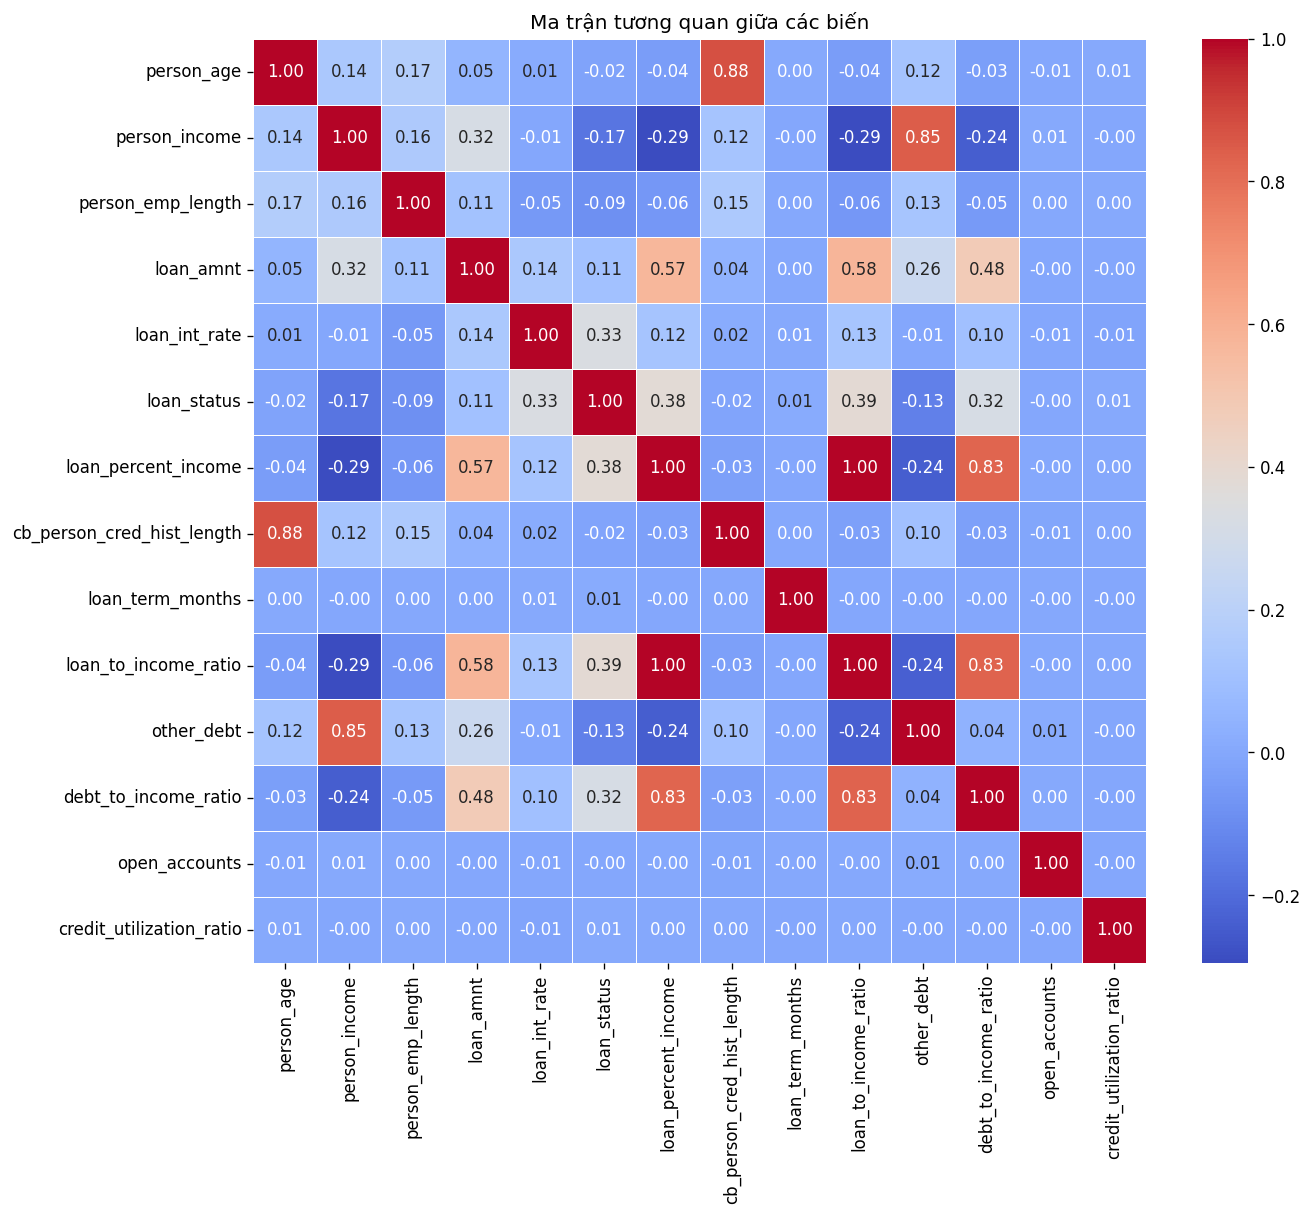

In [70]:
# Chọn các cột số để tính ma trận tương quan
numerical_cols = ['person_age', 'person_income','person_emp_length','loan_amnt',
                  'loan_int_rate', 'loan_status', 'loan_percent_income',
                  'cb_person_cred_hist_length','loan_term_months', 'loan_to_income_ratio',
                  'other_debt', 'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio',
                  ]
# Tính ma trận tương quan
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Ma trận tương quan giữa các biến')
plt.show()

Nhận xét về tương quan giữa các biến

1.  **Biến mục tiêu `loan_status` (tình trạng nợ xấu) có mối tương quan mạnh nhất với:**
    *   `loan_int_rate` (lãi suất khoản vay): Tương quan dương mạnh (0.42). Lãi suất càng cao, khả năng vỡ nợ càng lớn.
    *   `loan_percent_income` (tỷ lệ khoản vay trên thu nhập) và `loan_to_income_ratio` (tỷ lệ khoản vay trên thu nhập): Tương quan dương mạnh (0.37). Khi tỷ lệ này càng cao, gánh nặng tài chính càng lớn, dẫn đến rủi ro vỡ nợ cao hơn.
    *   `person_income` (thu nhập cá nhân): Tương quan âm vừa phải (-0.33). Thu nhập càng cao, khả năng vỡ nợ càng thấp.
    *   `loan_amnt` (số tiền vay): Tương quan dương yếu (0.16). Số tiền vay lớn hơn có xu hướng đi kèm với rủi ro vỡ nợ cao hơn một chút.
    *   `debt_to_income_ratio` (tỷ lệ nợ trên thu nhập): Tương quan dương yếu (0.13).

2.  **Các biến có mối tương quan yếu hoặc không đáng kể với `loan_status`:**
    *   `person_age`, `person_emp_length`,`loan_term_months`, `open_accounts`, `credit_utilization_ratio`, `past_delinquencies` đều có giá trị tương quan rất thấp (gần 0), cho thấy chúng ít ảnh hưởng trực tiếp đến khả năng vỡ nợ của khách hàng trong mối quan hệ tuyến tính.

3.  **Vấn đề đa cộng tuyến (Multicollinearity) giữa các biến độc lập:**
    *   `loan_percent_income` và `loan_to_income_ratio` có mối tương quan cực kỳ cao (0.99). Điều này cho thấy hai biến này gần như đo lường cùng một thông tin. Cần loại bỏ một trong hai biến để tránh đa cộng tuyến khi xây dựng mô hình
    * `debt_to_income_ratio` và `loan_percent_income`, `loan_to_income_ratio` cũng có mối tương quan cao (0.83)
    *   `loan_amnt` có mối tương quan vừa phải với `loan_int_rate` (0.50) và `person_income` (0.43). vì thường số tiền vay lớn hơn có thể đi kèm với lãi suất cao hơn hoặc yêu cầu thu nhập cao hơn.
    *   `loan_int_rate` có tương quan dương mạnh với `loan_percent_income` (0.55) và `loan_to_income_ratio` (0.55).

## IV Features Selection


Tính WOE / IV...

IV Summary:
                                IV        Power  Selected
loan_percent_income         0.9377  Very Strong      True
loan_to_income_ratio        0.9346  Very Strong      True
loan_grade                  0.8729  Very Strong      True
loan_int_rate               0.7177  Very Strong      True
debt_to_income_ratio        0.5722  Very Strong      True
person_income               0.4431       Strong      True
person_home_ownership       0.3769       Strong      True
cb_person_default_on_file   0.1638       Medium      True
loan_intent                 0.0957         Weak      True
loan_amnt                   0.0747         Weak      True
person_emp_length           0.0501         Weak      True
emp_length_was_null         0.0081      Useless     False
person_age                  0.0047      Useless     False
cb_person_cred_hist_length  0.0041      Useless     False
credit_utilization_ratio    0.0008      Useless     False
open_accounts               0.0005      U

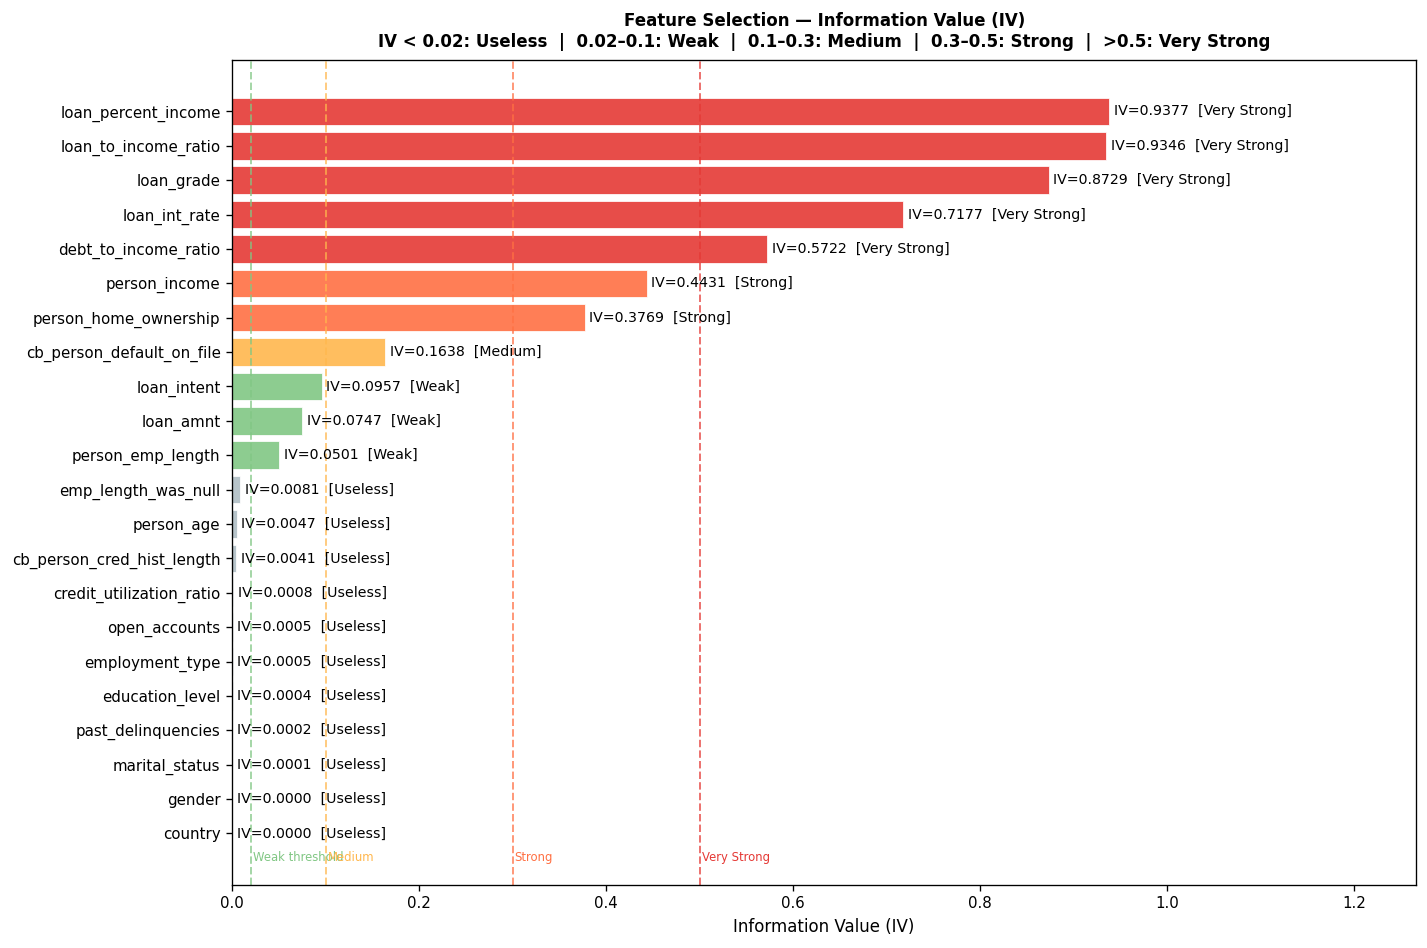

In [71]:
#  WOE / IV CALCULATION
# ══════════════════════════════════════════════════════════════════════
print("\nTính WOE / IV...")

total_event    = int(df2['loan_status'].sum())
total_nonevent = int((df2['loan_status'] == 0).sum())

def calc_woe_iv_num(df, feature, target, bins):
    """WOE/IV cho numerical feature với bins cố định"""
    temp = df2[[feature, target]].copy()
    temp['bin'] = pd.cut(pd.to_numeric(temp[feature], errors='coerce'), bins=bins)
    grp = temp.groupby('bin', observed=True)[target]\
              .agg(events='sum', total='count').copy()
    grp['non_events'] = grp['total'] - grp['events']
    grp['pct_e']  = (grp['events']  / total_event).clip(0.0001)
    grp['pct_ne'] = (grp['non_events'] / total_nonevent).clip(0.0001)
    grp['WOE']    = np.log(grp['pct_e'] / grp['pct_ne'])
    grp['IV']     = (grp['pct_e'] - grp['pct_ne']) * grp['WOE']
    grp['default_rate'] = grp['events'] / grp['total']
    return grp.round(4), round(grp['IV'].sum(), 4)

def calc_woe_iv_cat(df, feature, target):
    """WOE/IV cho categorical feature"""
    temp = df2[[feature, target]].copy()
    temp['bin'] = temp[feature].astype(str)
    grp = temp.groupby('bin')[target]\
              .agg(events='sum', total='count').copy()
    grp['non_events'] = grp['total'] - grp['events']
    grp['pct_e']  = (grp['events']  / total_event).clip(0.0001)
    grp['pct_ne'] = (grp['non_events'] / total_nonevent).clip(0.0001)
    grp['WOE']    = np.log(grp['pct_e'] / grp['pct_ne'])
    grp['IV']     = (grp['pct_e'] - grp['pct_ne']) * grp['WOE']
    grp['default_rate'] = grp['events'] / grp['total']
    return grp.round(4), round(grp['IV'].sum(), 4)

# Tính IV cho tất cả features
num_bins = {
    'loan_to_income_ratio':       [0, 0.1, 0.2, 0.3, 0.5, 1.1],
    'loan_percent_income':        [0, 0.05, 0.1, 0.15, 0.2, 0.3, 1.1],
    'loan_int_rate':              [0, 8, 11, 14, 17, 25],
    'debt_to_income_ratio':       [0, 0.2, 0.3, 0.4, 0.5, 1.1],
    'person_income':              [0, 38000, 55000, 79000, 2100000],
    'loan_amnt':                  [0, 5000, 10000, 15000, 20000, 35001],
    'person_emp_length':          [-1, 1, 3, 5, 10, 42],
    'person_age':                 [20, 25, 30, 35, 40, 80],
    'cb_person_cred_hist_length': [0, 2, 4, 6, 10, 31],
    'credit_utilization_ratio':   [0, 0.25, 0.5, 0.75, 1.01],
    'open_accounts':              [0, 4, 8, 12, 16],
    'past_delinquencies':         [-1, 0, 1, 2, 7],
}
cat_features = [
    'loan_grade', 'person_home_ownership', 'cb_person_default_on_file',
    'loan_intent', 'employment_type', 'education_level',
    'marital_status', 'gender','country','past_delinquencies',
    'emp_length_was_null' # Corrected typo here
]

iv_all = {}
woe_detail = {}

for feat, bins in num_bins.items():
    wdf, iv = calc_woe_iv_num(df2, feat, 'loan_status', bins)
    iv_all[feat] = iv
    woe_detail[feat] = wdf

for feat in cat_features:
    wdf, iv = calc_woe_iv_cat(df2, feat, 'loan_status')
    iv_all[feat] = iv
    woe_detail[feat] = wdf

iv_df = pd.DataFrame.from_dict(iv_all, orient='index', columns=['IV'])\
          .sort_values('IV', ascending=False)

# Gán nhãn predictive power
def iv_label(iv):
    if iv < 0.02:  return 'Useless'
    if iv < 0.1:   return 'Weak'
    if iv < 0.3:   return 'Medium'
    if iv < 0.5:   return 'Strong'
    return 'Very Strong'

iv_df['Power']    = iv_df['IV'].apply(iv_label)
iv_df['Selected'] = iv_df['IV'] >= 0.02  # ngưỡng tối thiểu để chọn vào model

print("\nIV Summary:")
print(iv_df.to_string())


# ══════════════════════════════════════════════════════════════════════
#  CHART 4 — IV BAR CHART
# ══════════════════════════════════════════════════════════════════════
print("\nVẽ Chart 4 — IV bar chart...")
fig, ax = plt.subplots(figsize=(12, 8))

colors_iv = []
for iv in iv_df['IV']:
    if iv < 0.02:   colors_iv.append('#B0BEC5')
    elif iv < 0.1:  colors_iv.append('#81C784')
    elif iv < 0.3:  colors_iv.append('#FFB74D')
    elif iv < 0.5:  colors_iv.append('#FF7043')
    else:           colors_iv.append('#E53935')

bars = ax.barh(iv_df.index, iv_df['IV'],
               color=colors_iv, edgecolor='white', linewidth=0.5, alpha=0.9)

# Ghi nhãn
for bar, (feat, row) in zip(bars, iv_df.iterrows()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"IV={row['IV']:.4f}  [{row['Power']}]",
            va='center', fontsize=8.5)

# Reference lines
for thresh, label, color in [
    (0.02, 'Weak threshold', '#81C784'),
    (0.1,  'Medium',         '#FFB74D'),
    (0.3,  'Strong',         '#FF7043'),
    (0.5,  'Very Strong',    '#E53935'),
]:
    ax.axvline(thresh, color=color, linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(thresh + 0.002, len(iv_df) - 0.5, label,
            fontsize=7, color=color, va='top')

ax.set_xlabel('Information Value (IV)', fontsize=10)
ax.set_title('Feature Selection — Information Value (IV)\n'
             'IV < 0.02: Useless  |  0.02–0.1: Weak  |  '
             '0.1–0.3: Medium  |  0.3–0.5: Strong  |  >0.5: Very Strong',
             fontsize=10, fontweight='bold', pad=8)
ax.set_xlim(0, iv_df['IV'].max() * 1.35)
ax.invert_yaxis()
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

## Tóm tắt lựa chọn biến và xử lý đa cộng tuyến

Dựa trên phân tích IV (Information Value) và các mối tương quan, tiến hành lựa chọn các biến quan trọng để đưa vào mô hình dự đoán nợ xấu.
- Các biến có IV dưới 0.02 (như `gender`, `marital_status`, `education_level`, `employment_type`, `credit_utilization_ratio`, `open_accounts`, `past_delinquencies`, `person_age`, `cb_person_cred_hist_length`, `emp_length_was_null`, và `country`) được coi là không có đủ sức mạnh dự đoán và đã bị loại bỏ khỏi tập dữ liệu để xây dựng mô hình.

**Xử lý Đa Cộng Tuyến:**

Để tránh tình trạng dư thừa thông tin và những vấn đề tiềm ẩn trong mô hình (như làm giảm độ ổn định của các hệ số hồi quy):

- Xử lý đa cộng tuyến (multicollinearity) giữa `loan_percent_income` và `loan_to_income_ratio`: giữ `loan_percent_income` vì có điểm IV cao hơn
- Tiếp tục loại bỏ biến `debt_to_income_ratio` vì có mối tương quan mạnh (0.83) với `loan_percent_income`.

*--> Các biến có giá trị IV từ 0.02 trở lên còn lại (từ "Weak" đến "Very Strong" predictive power) được giữ lại. Cụ thể, các biến được chọn là:*

**`loan_int_rate`, `loan_percent_income`, `person_income`, `loan_grade`, `person_home_ownership`, `cb_person_default_on_file`, `loan_intent`, `loan_amnt`, `person_emp_length`.**



## Chân dung khách hàng vỡ nợ

In [72]:
#  IN KẾT QUẢ: FEATURES SELECTED + CHÂN DUNG
# ══════════════════════════════════════════════════════════════════════
selected = iv_df[iv_df['IV'] >= 0.02].index.tolist()
dropped  = iv_df[iv_df['IV'] <  0.02].index.tolist()

print("\n" + "=" * 65)
print("KẾT QUẢ FEATURE SELECTION — IV/WOE")
print("=" * 65)
print(f"\nFeatures được chọn ({len(selected)}):")
for f in selected:
    print(f"  ✓ {f:<35} IV={iv_all[f]:.4f}  [{iv_label(iv_all[f])}]")
print(f"\nFeatures bị loại ({len(dropped)}) — IV < 0.02 (Useless):")
for f in dropped:
    print(f"  ✗ {f:<35} IV={iv_all[f]:.4f}")

print("""
══════════════════════════════════════════════════════════════
CHÂN DUNG NGƯỜI VỠ NỢ — KẾT LUẬN TỪ BIVARIATE + WOE/IV
══════════════════════════════════════════════════════════════

YẾU TỐ QUYẾT ĐỊNH (Very Strong / Strong — từ IV):
  Tỷ lệ vay/Thu nhập > 30%   → default rate nhảy từ 22% lên 68%
  Lãi suất > 14%             → default rate vượt 50%
  Loan Grade D trở lên       → 59–98% vỡ nợ
  Thu nhập Q1 (<$38K)        → 40% vỡ nợ, gấp 4.3x nhóm giàu nhất
  Thuê nhà (RENT)            → 31.5%, gấp 4.2x chủ nhà

YẾU TỐ BỔ SUNG (Medium):
  Lịch sử vỡ nợ (Y)          → 37.8%, gấp đôi nhóm sạch
  Vay trả nợ cũ / Y tế       → 26–28% default rate

KHÔNG CÓ PREDICTIVE POWER (loại khỏi model):
  gender, marital_status, education_level
  employment_type (IV=0.0004)
  credit_utilization_ratio, open_accounts, past_delinquencies

CHÂN DUNG ĐIỂN HÌNH:
  Thu nhập    ~$41,000/năm   (−32% so với nhóm không vỡ nợ)
  Nhà ở       Thuê (RENT)
  Loan Grade  D, E, F, G
  Lãi suất    ~13.5%         (+2.8 điểm %)
  Vay/TN      ~24%           (gần gấp đôi: 13% vs 24%)
  Nợ/TN       ~42%           (+10 điểm %)
  Mục đích    Trả nợ cũ hoặc Chi phí y tế bất ngờ
══════════════════════════════════════════════════════════════
""")


KẾT QUẢ FEATURE SELECTION — IV/WOE

Features được chọn (11):
  ✓ loan_percent_income                 IV=0.9377  [Very Strong]
  ✓ loan_to_income_ratio                IV=0.9346  [Very Strong]
  ✓ loan_grade                          IV=0.8729  [Very Strong]
  ✓ loan_int_rate                       IV=0.7177  [Very Strong]
  ✓ debt_to_income_ratio                IV=0.5722  [Very Strong]
  ✓ person_income                       IV=0.4431  [Strong]
  ✓ person_home_ownership               IV=0.3769  [Strong]
  ✓ cb_person_default_on_file           IV=0.1638  [Medium]
  ✓ loan_intent                         IV=0.0957  [Weak]
  ✓ loan_amnt                           IV=0.0747  [Weak]
  ✓ person_emp_length                   IV=0.0501  [Weak]

Features bị loại (11) — IV < 0.02 (Useless):
  ✗ emp_length_was_null                 IV=0.0081
  ✗ person_age                          IV=0.0047
  ✗ cb_person_cred_hist_length          IV=0.0041
  ✗ credit_utilization_ratio            IV=0.0008
  ✗ open_acco

## X, y Selection

In [73]:
df.columns

Index(['client_ID', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length', 'gender',
       'marital_status', 'education_level', 'country', 'state', 'city',
       'city_latitude', 'city_longitude', 'employment_type',
       'loan_term_months', 'loan_to_income_ratio', 'other_debt',
       'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio',
       'past_delinquencies', 'emp_length_was_null'],
      dtype='object')

In [74]:
# Chia features (X) and target (y)
features = ['loan_int_rate', 'loan_percent_income',
            'person_income','loan_grade', 'person_home_ownership',
            'cb_person_default_on_file', 'loan_intent','loan_amnt','person_emp_length']
X = df2[features]
y = df2['loan_status']

 ## Split train/test dataset

In [75]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Kích thước tập huấn luyện X_train:", X_train.shape)
print("Kích thước tập kiểm tra X_test:", X_test.shape)
print("Kích thước tập huấn luyện y_train:", y_train.shape)
print("Kích thước tập kiểm tra y_test:", y_test.shape)

Kích thước tập huấn luyện X_train: (26059, 9)
Kích thước tập kiểm tra X_test: (6515, 9)
Kích thước tập huấn luyện y_train: (26059,)
Kích thước tập kiểm tra y_test: (6515,)


## Encoding


In [76]:
import joblib

# Tạo bản sao để lưu kết quả WoE, giữ nguyên X_train/X_test gốc để đối chiếu nếu cần
X_train_woe = X_train.copy()
X_test_woe = X_test.copy()

# Tạo dictionary để lưu lại các "công thức" binning (rất quan trọng khi dự báo khách hàng mới)
binning_models = {}

for col in X_train.columns:
    # Tự động nhận dạng biến số hay chữ
    dtype = "categorical" if X_train[col].dtype == 'O' else "numerical"

    # Khởi tạo mô hình Binning
    optb = OptimalBinning(name=col, dtype=dtype, solver="cp")

    # Chỉ FIT trên tập TRAIN
    optb.fit(X_train[col], y_train)

    # Lưu lại bộ quy tắc của cột này
    binning_models[col] = optb

    # TRANSFORM cả Train và Test sang giá trị số WoE
    X_train_woe[col] = optb.transform(X_train[col], metric="woe")
    X_test_woe[col] = optb.transform(X_test[col], metric="woe")

# Lưu binning_models sau khi đã được tạo
joblib.dump(binning_models, 'binning_models.pkl')
print("Mô hình binning đã được lưu thành công vào 'binning_models.pkl'!")

Mô hình binning đã được lưu thành công vào 'binning_models.pkl'!


## Xử lý Imbalance

In [77]:
print("Phân phối gốc của tập Train:")
print(y_train.value_counts(normalize=True))

# Khởi tạo SMOTE
smote = SMOTE(random_state=42)

# Chỉ SMOTE trên tập TRAIN đã mã hóa
X_train_smote, y_train_smote = smote.fit_resample(X_train_woe, y_train)

print("\n--- Hoàn tất SMOTE ---")
print(f"Kích thước X_train ban đầu: {X_train_woe.shape[0]} dòng")
print(f"Kích thước X_train sau SMOTE: {X_train_smote.shape[0]} dòng")
print("\nPhân phối sau khi SMOTE:")
print(y_train_smote.value_counts(normalize=True))

Phân phối gốc của tập Train:
loan_status
0    0.781803
1    0.218197
Name: proportion, dtype: float64

--- Hoàn tất SMOTE ---
Kích thước X_train ban đầu: 26059 dòng
Kích thước X_train sau SMOTE: 40746 dòng

Phân phối sau khi SMOTE:
loan_status
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
X_train_smote.head()

,loan_int_rate,loan_percent_income,person_income,loan_grade,person_home_ownership,cb_person_default_on_file,loan_intent,loan_amnt,person_emp_length
0,-1.839414,0.651520,1.112754,-1.730750,0.669386,0.208058,-0.258071,-0.255074,-0.023552
1,0.891642,0.651520,1.026382,0.931388,-0.504077,0.208058,-0.349670,-0.255074,0.178377
2,-1.573501,0.816618,-0.823961,-1.730750,-0.504077,-0.760165,0.271312,-0.012280,-0.220974
3,1.005669,0.651520,0.471975,0.931388,0.669386,0.208058,0.131204,0.139411,0.178377
4,-0.303833,0.538185,1.112754,-1.730750,0.669386,0.208058,0.131204,-0.694223,0.295370


In [ ]:
X_test_woe.head()

,loan_int_rate,loan_percent_income,person_income,loan_grade,person_home_ownership,cb_person_default_on_file,loan_intent,loan_amnt,person_emp_length
23891,1.005669,0.538185,0.471975,0.931388,0.669386,0.208058,-0.258071,0.139411,0.178377
23573,-1.839414,-0.208675,-0.823961,-1.730750,-0.504077,0.208058,0.131204,0.139411,0.178377
9488,0.285714,0.651520,1.026382,0.351842,-0.504077,0.208058,-0.349670,0.217963,-0.220974
3671,-1.573501,-0.208675,-1.843840,-1.730750,-0.504077,-0.760165,0.458227,0.115875,0.178377
20936,0.328275,0.651520,1.112754,0.351842,-0.504077,0.208058,0.458227,0.139411,-0.023552


# Turning

## Tìm hyperparameter

In [ ]:
# DECISION TREE
# ============================================================

from sklearn.model_selection import GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, 15, None],
}
dtc_tur = DecisionTreeClassifier(max_depth=5)
grid_search = GridSearchCV(estimator=dtc_tur,
                           param_grid=param_grid,
                           cv=5, #cv = cross validation
                           scoring='recall',
                           n_jobs=-1,
                           verbose=1)
grid_search.fit(X_train_smote, y_train_smote)

print(f"Bộ tham số tốt nhất: {grid_search.best_params_}")
print(f"Độ chính xác tốt nhất trên tập train: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Bộ tham số tốt nhất: {'criterion': 'entropy', 'max_depth': None}
Độ chính xác tốt nhất trên tập train: 0.9145


In [ ]:
# RANDOM FOREST
# ============================================================

rf_params = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None,5, 10, 20]
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    cv=5, scoring='recall',
    n_jobs=-1, verbose=1)

rf_gs.fit(X_train_smote, y_train_smote)

print(f"\n  Best params  : {rf_gs.best_params_}")
print(f"  Best score : {rf_gs.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits

  Best params  : {'max_depth': None, 'n_estimators': 300}
  Best roc_auc : 0.9224


In [ ]:
# LOGISTIC REGRESSION
# ============================================================
lr_params = {
    'C':        [0.01, 0.1, 1, 10, 100],
    'penalty':  ['l1', 'l2'],
}

lr_gs = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params,
    cv=5, scoring='recall',
    n_jobs=-1, verbose=1)

lr_gs.fit(X_train_smote, y_train_smote)

print(f"\n  Best params  : {lr_gs.best_params_}")
print(f"  Best score  : {lr_gs.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

  Best params  : {'C': 10, 'penalty': 'l2'}
  Best score  : 0.8085


In [ ]:
# KNN
# ============================================================

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
}

knn_gs = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5, scoring='recall',
    n_jobs=-1, verbose=1)

knn_gs.fit(X_train_smote, y_train_smote)

print(f"\n  Best params  : {knn_gs.best_params_}")
print(f"  Best score  : {knn_gs.best_score_:.4f}")


Fitting 5 folds for each of 7 candidates, totalling 35 fits

  Best params  : {'n_neighbors': 3}
  Best score  : 0.9364


In [ ]:
# SVC
# ============================================================

svc_params = {
    'kernel': ['rbf', 'linear']
}

svc_gs = GridSearchCV(
    SVC(probability=True, random_state=42),
    svc_params,
    cv=5, scoring='recall',
    n_jobs=-1, verbose=1)

svc_gs.fit(X_train_smote, y_train_smote)

print(f"\n  Best params  : {svc_gs.best_params_}")
print(f"  Best score  : {svc_gs.best_score_:.4f}")

Fitting 5 folds for each of 2 candidates, totalling 10 fits

  Best params  : {'kernel': 'linear'}
  Best score  : 0.7943


# Model Training

In [79]:
# 1.Khởi tạo mô hình Decision Tree
dtc = DecisionTreeClassifier(criterion='entropy', max_depth=None, random_state=42)

# Huấn luyện mô hình
dtc.fit(X_train_smote, y_train_smote)

# Dự đoán trên tập kiểm tra
y_pred_dtc = dtc.predict(X_test_woe)

print("Mô hình Decision Tree đã được huấn luyện thành công.")

Mô hình Decision Tree đã được huấn luyện thành công.


In [78]:
# 2.Khởi tạo mô hình Random Forest
rfc = RandomForestClassifier(n_estimators=300, max_depth = None, random_state=42)

# Huấn luyện mô hình
rfc.fit(X_train_smote, y_train_smote)

# Dự đoán trên tập kiểm tra
y_pred_rfc = rfc.predict(X_test_woe)

print("Mô hình Random Forest đã được huấn luyện thành công.")

Mô hình Random Forest đã được huấn luyện thành công.


In [ ]:
# 3. Khởi tạo và huấn luyện mô hình Logistic Regression
lr = LogisticRegression(C=10, penalty= 'l2', random_state=42)
lr.fit(X_train_smote, y_train_smote)

# Dự đoán trên tập kiểm tra
y_pred_lr = lr.predict(X_test_woe)

print("Mô hình Logistic Regression đã được huấn luyện thành công.")

In [ ]:
# 4. Khởi tạo và huấn luyện mô hình K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_smote, y_train_smote)

# Dự đoán trên tập kiểm tra
y_pred_knn = knn.predict(X_test_woe)

print("Mô hình KNN đã được huấn luyện thành công.")

In [ ]:
# 5. Khởi tạo và huấn luyện mô hình Support Vector Classifier (SVC)
svc = SVC(kernel = 'linear', random_state=42, probability=True)
svc.fit(X_train_smote, y_train_smote)

# Dự đoán trên tập kiểm tra
y_pred_svc = svc.predict(X_test_woe)

print("Mô hình SVC đã được huấn luyện thành công.")

Mô hình SVC đã được huấn luyện thành công.


# Model Evaluation

Đánh giá mô hình Decision Tree:
Accuracy: 0.8821
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      5094
           1       0.72      0.74      0.73      1421

    accuracy                           0.88      6515
   macro avg       0.83      0.83      0.83      6515
weighted avg       0.88      0.88      0.88      6515

Confusion Matrix:


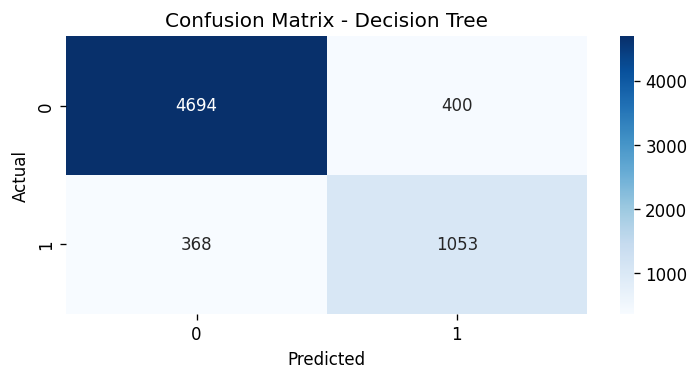

In [ ]:
# Đánh giá mô hình Decision Tree
print("Đánh giá mô hình Decision Tree:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dtc):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_dtc))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_dtc), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Đánh giá mô hình Random Forest:
Accuracy: 0.9182
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      5094
           1       0.89      0.72      0.79      1421

    accuracy                           0.92      6515
   macro avg       0.91      0.85      0.87      6515
weighted avg       0.92      0.92      0.91      6515

Confusion Matrix:


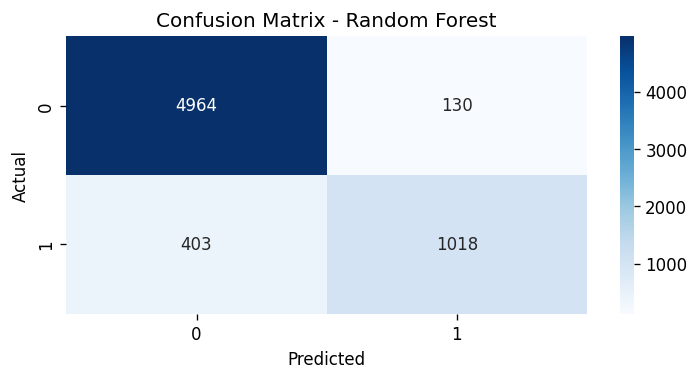

In [81]:
# Đánh giá mô hình Random Forest
print("\nĐánh giá mô hình Random Forest:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rfc):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rfc))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_rfc), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Đánh giá mô hình Logistic Regression:
Accuracy: 0.8244
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.84      0.88      5094
           1       0.57      0.79      0.66      1421

    accuracy                           0.82      6515
   macro avg       0.75      0.81      0.77      6515
weighted avg       0.85      0.82      0.83      6515

Confusion Matrix:


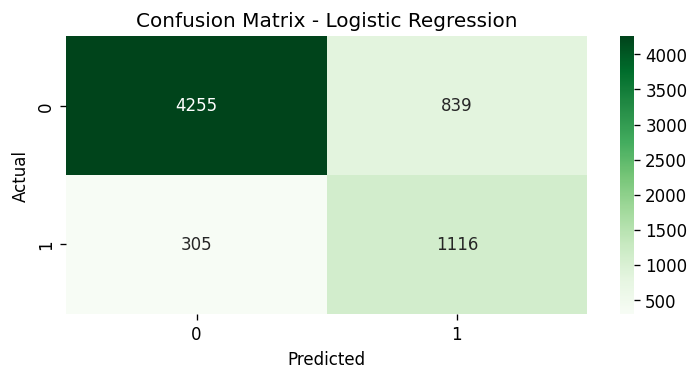

In [ ]:
# Đánh giá mô hình Logistic Regression
print("Đánh giá mô hình Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Đánh giá mô hình KNN:
Accuracy: 0.8309
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89      5094
           1       0.59      0.77      0.67      1421

    accuracy                           0.83      6515
   macro avg       0.76      0.81      0.78      6515
weighted avg       0.85      0.83      0.84      6515

Confusion Matrix:


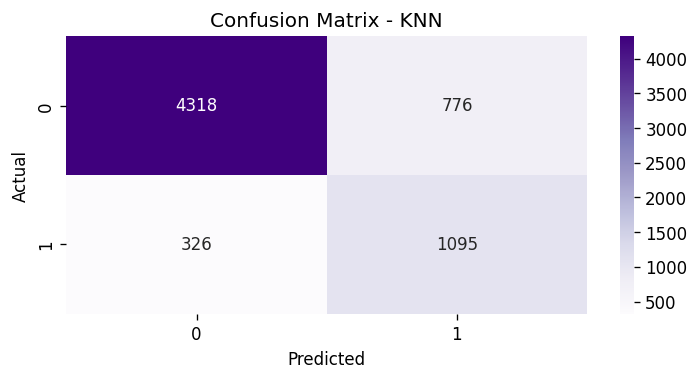

In [ ]:
# Đánh giá mô hình KNN
print("Đánh giá mô hình KNN:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Đánh giá mô hình SVC:
Accuracy: 0.8322
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89      5094
           1       0.59      0.77      0.67      1421

    accuracy                           0.83      6515
   macro avg       0.76      0.81      0.78      6515
weighted avg       0.86      0.83      0.84      6515

Confusion Matrix:


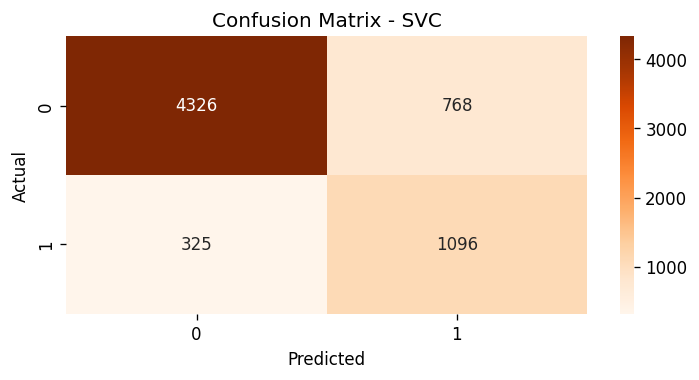

In [ ]:
# Đánh giá mô hình SVC
print("Đánh giá mô hình SVC:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_svc))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_svc), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - SVC')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Kết luận
- Logistic Regression, SVC và KNN bắt được nhiều ca vỡ nợ hơn nhưng báo nhầm nhiều hơn. Random Forest và Decision Tree báo chính xác hơn nhưng bỏ sót nhiều ca hơn một chút.
- Với bài toán tín dụng, chi phí bỏ sót 1 ca vỡ nợ (mất toàn bộ vốn gốc) thường lớn hơn chi phí từ chối nhầm 1 khách tốt (mất 1 khoản lãi) → Recall quan trọng hơn Precision. Tuy nhiên Random Forest vẫn được chọn vì F1 cao nhất — cân bằng tốt nhất giữa hai mục tiêu.

# Deployment

Sử dụng mô hình Random Forest để thiết lập giao diện mô hình thẩm định tín dụng

In [79]:
!pip install joblib

In [80]:
import joblib

joblib.dump(rfc, 'model_rfc.pkl')

print("Mô hình rfc đã được lưu thành công!")

Mô hình rfc đã được lưu thành công!


In [81]:
import gradio as gr
import pandas as pd
import joblib

try:
    rfc_model = joblib.load('model_rfc.pkl')
    loaded_binning_models = joblib.load('binning_models.pkl')
    print("Đã tải mô hình thành công!")
except Exception as e:
    print(f"Lỗi tải mô hình: {e}")
    rfc_model = None
    loaded_binning_models = None

def predict_bad_debt(loan_int_rate, loan_percent_income, person_income, loan_grade,
                     person_home_ownership, cb_person_default_on_file, loan_intent,
                     loan_amnt, person_emp_length):

    if rfc_model is None:
        return "⚠️ Lỗi: Không thể tải mô hình."

    # Xử lý dữ liệu đầu vào (Giữ nguyên logic transform của bạn)
    input_data = {
        'loan_int_rate': [loan_int_rate],
        'loan_percent_income': [loan_percent_income / 100], # Chia 100 nếu người dùng nhập số nguyên
        'person_income': [person_income],
        'loan_grade': [loan_grade],
        'person_home_ownership': [person_home_ownership],
        'cb_person_default_on_file': [cb_person_default_on_file],
        'loan_intent': [loan_intent],
        'loan_amnt': [loan_amnt],
        'person_emp_length': [person_emp_length]
    }
    input_df = pd.DataFrame(input_data)
    transformed_input = input_df.copy()

    for col in input_df.columns:
        if col in loaded_binning_models:
            try:
                transformed_input[col] = loaded_binning_models[col].transform(input_df[col], metric="woe")
            except:
                transformed_input[col] = 0

    prediction = rfc_model.predict(transformed_input)[0]
    prediction_proba = rfc_model.predict_proba(transformed_input)[:, 1][0]

    # Thiết kế giao diện kết quả (HTML)
    color = "#e74c3c" if prediction == 1 else "#27ae60"
    status = "⚠️ NGUY CƠ NỢ XẤU CAO" if prediction == 1 else "✅ HỒ SƠ AN TOÀN"
    bg_color = "rgba(231, 76, 60, 0.1)" if prediction == 1 else "rgba(39, 174, 96, 0.1)"

    html_result = f"""
    <div style="padding: 20px; border-radius: 10px; background-color: {bg_color}; border: 2px solid {color}; text-align: center;">
        <h2 style="color: {color}; margin: 0;">{status}</h2>
        <p style="font-size: 1.2em; margin-top: 10px;">Xác suất vỡ nợ: <strong style="font-size: 1.5em;">{prediction_proba:.2%}</strong></p>
        <p style="color: #555;">Hệ thống khuyến nghị: {"Từ chối hoặc yêu cầu thêm tài sản đảm bảo" if prediction == 1 else "Có thể xem xét giải ngân nhanh"}</p>
    </div>
    """
    return html_result

# CSS chuyên nghiệp cho Banking App
custom_css = """
.gradio-container { background-color: #f4f7f6; }
.header-box { text-align: center; padding: 20px; background: linear-gradient(90deg, #1a2a6c, #b21f1f, #fdbb2d); color: white; border-radius: 10px; margin-bottom: 20px; }
.input-group { background: white; padding: 15px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0,0,0,0.05); }
#predict-btn { background-color: #1a2a6c !important; color: white !important; font-weight: bold !important; border-radius: 5px !important; }
label { font-weight: 600 !important; color: #2c3e50 !important; }
"""

with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:
    # Header
    gr.HTML("""
    <div class="header-box">
        <h1>🏦 NOVABANK - CREDIT RISK</h1>
        <p>Mô hình thẩm định tín dụng tự động</p>
    </div>
    """)

    with gr.Row():
        # Cột 1: Thông tin khách hàng
        with gr.Column(scale=1):
            gr.Markdown("### 👤 Thông tin định danh & Tài chính")
            with gr.Group():
                income = gr.Number(label="💰 Thu nhập hàng năm (USD)", value=50000)
                emp_length = gr.Number(label="💼 Số năm kinh nghiệm làm việc", value=4.0)
                home_ownership = gr.Dropdown(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], label="🏠 Tình trạng sở hữu nhà", value='RENT')
                prior_default = gr.Radio(['Y', 'N'], label="🚩 Tiền lệ nợ xấu (Dữ liệu CIC)", value='N')

        # Cột 2: Thông tin khoản vay
        with gr.Column(scale=1):
            gr.Markdown("### 📝 Chi tiết khoản vay")
            with gr.Group():
                loan_amnt = gr.Number(label="💵 Số tiền vay (USD)", value=8000)
                loan_rate = gr.Number(label="📈 Lãi suất (%)", value=10.0)
                loan_ratio = gr.Slider(0, 100, label="📊 Tỷ lệ vay/Thu nhập (%)", value=15)
                loan_intent = gr.Dropdown(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION'], label="🎯 Mục đích vay vốn", value='EDUCATION')
                loan_grade = gr.Dropdown(['A', 'B', 'C', 'D', 'E', 'F', 'G'], label="⭐ Xếp hạng khoản vay nội bộ", value='B')

    # Nút bấm và Kết quả
    with gr.Row():
        predict_btn = gr.Button("PHÂN TÍCH RỦI RO TÍN DỤNG", variant="primary", elem_id="predict-btn")

    output = gr.HTML(label="Kết quả phân tích")

    # Event listener
    predict_btn.click(
        fn=predict_bad_debt,
        inputs=[loan_rate, loan_ratio, income, loan_grade, home_ownership, prior_default, loan_intent, loan_amnt, emp_length],
        outputs=output
    )

    gr.Markdown("<p style='text-align: center; color: #888;'>© 2026 NovaBank Risk Management Department - Confidential</p>")

demo.launch()

Đã tải mô hình thành công!
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c95a37e58f6c54d6dc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
